In [ ]:
import pyreadstat   # Import library to read Stata files
# Read the NFHS-5 .DTA dataset and its metadata
df, meta = pyreadstat.read_dta("../data/raw/IABR7EFL.DTA")
print(df.shape)   # Show number of rows and columns
print(meta.column_labels[:20])   # Show labels of first 20 variables

In [ ]:
# Loop through every variable name and its label together
for name, label in zip(meta.column_names, meta.column_labels):
    # Check if the label exists and contains keywords related to C-section or delivery
    if label and ('cesar' in label.lower() or 'caesar' in label.lower() or 'delivery' in label.lower()):
        # Print the variable name and its corresponding label
        print(name, "->", label)

v401 -> last birth a caesarean section
m15 -> place of delivery
m17 -> delivery by caesarean section
m17a -> timing on decision for caesarean section
m54 -> na - received vitamin a dose in first 2 months after delivery
m61 -> time spent at place of delivery
m66 -> respondent's health checked after discharge/delivery at home
m67 -> how long after discharge/delivery at home respondent health check took place
m68 -> who checked respondent health after discharge/delivery at home
m69 -> where respondent check after discharge/delivery at home took place
m71 -> time after delivery postnatal check took place
s365d -> services/matters talked about in last 3 months: delivery care
s370d -> service went for: delivery care
s441 -> during delivery, did you experience a breech presentation?
s442 -> during delivery, did you experience prolonged labour?
s443 -> during delivery, did you experience excessive bleeding?
s449 -> transport used by respondent to go to health facility for delivery
s451 -> resp

In [ ]:
# Inspect delivery-related variables, decode their value labels,
# and keep only records with valid delivery information.

# Count all values in m17, including missing values
df['m17'].value_counts(dropna=False)

# Count all values in m15, including missing values
df['m15'].value_counts(dropna=False)

# Print the value labels for m15
print(meta.variable_value_labels['m15'])

# Print the value labels for m17
print(meta.variable_value_labels['m17'])

# Print the value labels for m17a
print(meta.variable_value_labels['m17a'])

# Keep only rows with a recorded place of delivery
df_delivery = df[df['m15'].notna()].copy()

# Show the size of the filtered dataset
print(df_delivery.shape)

{10: 'home', 11: "respondent's home", 12: 'other home', 13: "parents' home", 20: 'public sector', 21: 'public: govt./munic. hospital', 22: 'public: govt. dispensary', 23: 'public: uhc/uhp/ufwc', 24: 'public: chc/rural hospital/block phc', 25: 'public: phc/additional phc', 26: 'public: sub-centre', 27: 'other public sector health facility', 30: 'private sector', 31: 'private: hospital/maternity home/clinic', 32: 'other private sector health facility', 33: 'ngo or trust hospital/clinic', 96: 'other'}
{0: 'no', 1: 'yes'}
{1: 'before labor started', 2: 'after labor started', 8: "don't know"}
(232920, 1644)


In [ ]:
# Filter delivery records, group delivery locations into facility types,
# keep only institutional births, and create the binary C-section target variable.

# Keep only rows with a recorded place of delivery
df_delivery = df[df['m15'].notna()].copy()

# Function to group detailed delivery locations into broader categories
def recode_facility(code):

    # Home deliveries
    if code in [10, 11, 12, 13]:
        return 'home'

    # Government/public health facilities
    elif 20 <= code <= 27:
        return 'public'

    # Private health facilities
    elif 30 <= code <= 33:
        return 'private'

    # Other delivery locations
    else:  # 96 = other
        return 'other'

# Create a new column with the grouped facility type
df_delivery['facility_type'] = df_delivery['m15'].apply(recode_facility)

# Check the number of deliveries in each facility type
print(df_delivery['facility_type'].value_counts())

# Keep only institutional deliveries (exclude home births)
df_institutional = df_delivery[
    df_delivery['facility_type'].isin(['public', 'private', 'other'])
].copy()

# Show the size of the institutional delivery dataset
print(df_institutional.shape)

# Create the binary target variable (0 = No C-section, 1 = C-section)
df_institutional['csection'] = df_institutional['m17']

# Check the distribution of the target variable
print(df_institutional['csection'].value_counts(dropna=False))

facility_type
public     150299
private     50495
home        31609
other         517
Name: count, dtype: int64
(201311, 1645)
csection
0    156569
1     44742
Name: count, dtype: int64


In [ ]:
#to understand the distribution of the target variable (csection) before building the ML model.
df_institutional['csection'].mean() * 100
df_institutional.groupby('facility_type')['csection'].mean() * 100

facility_type
other            0.0
private    47.079909
public     13.951523
Name: csection, dtype: object

In [ ]:
#seeing all variables 
for name, label in zip(meta.column_names, meta.column_labels):
    print(name, "->", label)

caseid -> case identification
bidx -> birth column number
v000 -> country code and phase
v001 -> cluster number
v002 -> household number
v003 -> respondent's line number
v004 -> ultimate area unit
v005 -> women's individual sample weight (6 decimals)
v006 -> month of interview
v007 -> year of interview
v008 -> date of interview (cmc)
v008a -> date of interview century day code (cdc)
v009 -> respondent's month of birth
v010 -> respondent's year of birth
v011 -> date of birth (cmc)
v012 -> respondent's current age
v013 -> age in 5-year groups
v014 -> completeness of age information
v015 -> result of individual interview
v016 -> day of interview
v017 -> cmc start of calendar
v018 -> row of month of interview
v019 -> length of calendar
v019a -> number of calendar columns
v020 -> ever-married sample
v021 -> primary sampling unit
v022 -> sample strata for sampling errors
v023 -> stratification used in sample design
v024 -> state
v025 -> type of place of residence
v026 -> na - de facto place 

In [ ]:
# This code checks all possible NFHS-5 predictors before building the final
# C-section prediction dataset. It confirms whether each variable exists,
# examines its labels and missing values, checks for unusual DHS codes,
# and flags variables that may cause data leakage.

import pandas as pd
import numpy as np


# List all variables that may be useful for predicting C-section delivery.
# These variables are only being checked at this stage and are not yet finalized.

candidates = [
    # m17 records whether the birth was delivered by C-section
    'm17',

    # m15 records the place where the delivery occurred
    'm15',

    # Mother's demographic and socioeconomic details
    'v012',  # Mother's current age
    'v013',  # Mother's age group
    'v106',  # Mother's highest education level
    'v133',  # Total completed years of education
    'v190',  # Household wealth index
    'v025',  # Urban or rural residence
    'v130',  # Religion
    'v131',  # Caste or tribe category
    's116',  # Social group or caste category from the India questionnaire
    'v701',  # Husband or partner's education level
    'v704',  # Husband or partner's occupation
    'v705',  # Grouped husband or partner occupation
    'v481',  # Whether the mother has health insurance

    # Mother's health and previous pregnancy history
    'v445',  # Mother's BMI stored with an implied decimal
    'v437',  # Mother's weight
    'v438',  # Mother's height
    'bord',  # Birth order of the child
    'v201',  # Total number of children ever born
    'b11',   # Previous birth interval
    'v212',  # Mother's age at first birth

    # Antenatal care details
    'm13',  # Month of pregnancy when the first ANC visit occurred
    'm14',  # Total number of ANC visits

    # Individual services or checks received during antenatal care
    'm2a', 'm2b', 'm2c', 'm2d', 'm2e', 'm2f',
    'm2g', 'm2h', 'm2i', 'm2j', 'm2k', 'm2l',
    'm2m', 'm2n',

    # Pregnancy-related information and possible complications
    'm43',
    's420a', 's420b', 's420c', 's420d', 's420e',
    's434', 's435',

    # Checks or services received as part of antenatal care
    'm42a', 'm42b', 'm42c', 'm42d', 'm42e',

    # People who assisted during delivery
    # Their timing must be checked before they can be used as predictors
    'm3a', 'm3b', 'm3c', 'm3d', 'm3e', 'm3f',
    'm3g', 'm3h', 'm3i', 'm3j', 'm3k', 'm3l',
    'm3m', 'm3n',

    # These variables may contain information from during or after delivery
    # They are included here only so that possible leakage can be verified
    's441', 's442', 's443',
    'm17a'
]


# Separate the requested variables into those that are present in the
# institutional-delivery dataset and those that could not be found.

available = [
    v for v in candidates
    if v in df_institutional.columns
]

missing = [
    v for v in candidates
    if v not in df_institutional.columns
]


# Show which candidate variables are available in the dataset.

print("AVAILABLE VARIABLES")
print(available)


# Show which requested variables are not present in the dataset.

print("\nVARIABLES NOT FOUND")
print(missing)


# Print a short count summary.

print("\nTotal candidates :", len(candidates))
print("Available        :", len(available))
print("Not found        :", len(missing))


# Create a dictionary that connects every DHS variable name with its
# full descriptive label from the Stata metadata.

label_dict = dict(
    zip(meta.column_names, meta.column_labels)
)


# Each variable's verification details will be stored in this list.

meta_rows = []


# Go through every proposed variable and collect its basic information.

for v in candidates:

    # If the variable is absent, record it as not found.
    if v not in df_institutional.columns:

        meta_rows.append({
            'var': v,
            'label': label_dict.get(v, ''),
            'status': 'NOT FOUND',
            'dtype': '',
            'n_missing': np.nan,
            'pct_missing': np.nan,
            'n_unique': np.nan,
            'value_labels': {}
        })

        # Move directly to the next variable because no column data is available.
        continue

    # Get the meanings of coded values, such as 0 = No and 1 = Yes.
    # An empty dictionary is returned when the variable has no value labels.
    labels = meta.variable_value_labels.get(v, {})

    # Store the variable's label, datatype, missingness and number of unique values.
    meta_rows.append({
        'var': v,
        'label': label_dict.get(v, ''),
        'status': 'AVAILABLE',
        'dtype': str(df_institutional[v].dtype),
        'n_missing': int(df_institutional[v].isna().sum()),
        'pct_missing': round(
            df_institutional[v].isna().mean() * 100, 2
        ),
        'n_unique': int(
            df_institutional[v].nunique(dropna=True)
        ),
        'value_labels': labels
    })


# Convert the collected variable information into one verification table.

verify_df = pd.DataFrame(meta_rows)


# Print the official DHS label and coded-value meanings for every
# candidate variable that is available in the dataset.

print("\nDHS VALUE LABELS")

for v in available:

    print(f"\n--- {v} ---")
    print("Variable:", label_dict.get(v, ''))

    # Retrieve the value-label dictionary for the current variable.
    labels = meta.variable_value_labels.get(v, {})

    # Print the coded meanings when they exist.
    if labels:
        print("Value labels:", labels)
    else:
        print("No value labels available")


# Look for common DHS special codes that may represent responses such as
# don't know, not applicable, missing or other non-standard answers.

print("\nCOMMON SPECIAL-CODE CHECK")

special_codes = [
    7, 8, 9,
    97, 98, 99,
    997, 998, 999,
    9997, 9998, 9999
]


# Check every available variable for the special values listed above.

for v in available:

    # Select the current variable as a pandas Series.
    series = df_institutional[v]

    # Store any special values found in this variable and their counts.
    found_codes = []

    for code in special_codes:

        # Check whether the current special code appears at least once.
        if (series == code).any():

            # Count how many records contain that code.
            count = int((series == code).sum())
            found_codes.append((code, count))

    # Only print variables in which at least one special code was found.
    if found_codes:
        print(f"\n{v} -> {label_dict.get(v, '')}")
        print(found_codes)


# Create a simpler table showing missingness only for variables that
# are actually available in the institutional-delivery dataset.

missingness_df = (
    verify_df[
        verify_df['status'] == 'AVAILABLE'
    ][
        ['var', 'label', 'n_missing', 'pct_missing', 'n_unique']
    ]
    .sort_values('pct_missing', ascending=False)
)


# Display variables from highest to lowest percentage of missing data.

print("\nMISSINGNESS")
display(missingness_df)


# Manually classify when each variable becomes known.
# This is used to prevent the model from learning from information that
# would only become available during or after the delivery.

timing_review = {

    # Mother's age is already known before delivery
    'v012': 'PRE-DELIVERY',

    # Mother's age group is already known before delivery
    'v013': 'PRE-DELIVERY',

    # Mother's education level is known before delivery
    'v106': 'PRE-DELIVERY',

    # Mother's completed education years are known before delivery
    'v133': 'PRE-DELIVERY',

    # Household wealth category is known before delivery
    'v190': 'PRE-DELIVERY',

    # Urban or rural residence is known before delivery
    'v025': 'PRE-DELIVERY',

    # Religion is known before delivery
    'v130': 'PRE-DELIVERY',

    # Caste or tribe category is known before delivery
    'v131': 'PRE-DELIVERY',

    # Social group or caste category is known before delivery
    's116': 'PRE-DELIVERY',

    # Husband or partner's education is known before delivery
    'v701': 'PRE-DELIVERY',

    # Husband or partner's occupation is known before delivery
    'v704': 'PRE-DELIVERY',

    # Grouped husband or partner occupation is known before delivery
    'v705': 'PRE-DELIVERY',

    # Health-insurance status is known before delivery
    'v481': 'PRE-DELIVERY',

    # Mother's BMI is measurable before delivery
    'v445': 'PRE-DELIVERY',

    # Mother's weight is measurable before delivery
    'v437': 'PRE-DELIVERY',

    # Mother's height is fixed and known before delivery
    'v438': 'PRE-DELIVERY',

    # Birth order is known before the current delivery
    'bord': 'PRE-DELIVERY',

    # Number of children ever born is based on previous reproductive history
    'v201': 'PRE-DELIVERY',

    # Previous birth interval is known from birth history
    'b11': 'PRE-DELIVERY',

    # Mother's age at first birth is part of her previous history
    'v212': 'PRE-DELIVERY',

    # Timing of the first ANC visit is known before delivery
    'm13': 'PRE-DELIVERY',

    # Number of ANC visits is known before delivery
    'm14': 'PRE-DELIVERY',

    # The exact meaning and questionnaire timing of these ANC variables
    # must be confirmed before deciding whether they are safe predictors.
    'm2a': 'VERIFY TIMING',
    'm2b': 'VERIFY TIMING',
    'm2c': 'VERIFY TIMING',
    'm2d': 'VERIFY TIMING',
    'm2e': 'VERIFY TIMING',
    'm2f': 'VERIFY TIMING',
    'm2g': 'VERIFY TIMING',
    'm2h': 'VERIFY TIMING',
    'm2i': 'VERIFY TIMING',
    'm2j': 'VERIFY TIMING',
    'm2k': 'VERIFY TIMING',
    'm2l': 'VERIFY TIMING',
    'm2m': 'VERIFY TIMING',
    'm2n': 'VERIFY TIMING',

    # The questionnaire timing of m43 needs to be confirmed
    'm43': 'VERIFY TIMING',

    # These pregnancy-complication variables need questionnaire review
    # to confirm whether the information was available before delivery.
    's420a': 'VERIFY TIMING',
    's420b': 'VERIFY TIMING',
    's420c': 'VERIFY TIMING',
    's420d': 'VERIFY TIMING',
    's420e': 'VERIFY TIMING',

    # These additional pregnancy-related variables also need timing review.
    's434': 'VERIFY TIMING',
    's435': 'VERIFY TIMING',

    # These antenatal-care quality variables need their exact timing checked.
    'm42a': 'VERIFY TIMING',
    'm42b': 'VERIFY TIMING',
    'm42c': 'VERIFY TIMING',
    'm42d': 'VERIFY TIMING',
    'm42e': 'VERIFY TIMING',

    # Place of delivery may only be known once the delivery location is chosen.
    # Whether it is safe depends on when the final model is intended to predict.
    'm15': 'VERIFY TIMING',

    # These variables describe who assisted with the delivery.
    # They may only be known during delivery, so they need careful review.
    'm3a': 'VERIFY TIMING',
    'm3b': 'VERIFY TIMING',
    'm3c': 'VERIFY TIMING',
    'm3d': 'VERIFY TIMING',
    'm3e': 'VERIFY TIMING',
    'm3f': 'VERIFY TIMING',
    'm3g': 'VERIFY TIMING',
    'm3h': 'VERIFY TIMING',
    'm3i': 'VERIFY TIMING',
    'm3j': 'VERIFY TIMING',
    'm3k': 'VERIFY TIMING',
    'm3l': 'VERIFY TIMING',
    'm3m': 'VERIFY TIMING',
    'm3n': 'VERIFY TIMING',

    # m17 records whether the birth was delivered by C-section.
    # It is the outcome that the model will predict.
    'm17': 'OUTCOME — TARGET',

    # m17a contains information connected to the C-section outcome
    # and may reveal the answer to the model.
    'm17a': 'POST-OUTCOME / LEAKAGE',

    # These variables contain information from during delivery,
    # so they should not be used for a pre-delivery prediction.
    's441': 'DURING DELIVERY — EXCLUDE',
    's442': 'DURING DELIVERY — EXCLUDE',
    's443': 'DURING DELIVERY — EXCLUDE'
}


# Add the timing category as a new column in the verification table.
# Any variable not manually classified above is marked for further review.

verify_df['timing'] = verify_df['var'].map(
    timing_review
).fillna('REVIEW')


# Give every variable a preliminary role in the project.
# This is only an initial decision and not the final feature selection.

def initial_decision(variable):

    # m17 is the C-section outcome that the model will predict.
    if variable == 'm17':
        return 'TARGET'

    # These variables may reveal information from during or after delivery.
    if variable in ['m17a', 's441', 's442', 's443']:
        return 'DROP — LEAKAGE'

    # These variables appear potentially useful, but their meaning,
    # timing, missingness and suitability still need to be confirmed.
    if variable in [
        'v012',  # Mother's age
        'v133',  # Completed years of education
        'v190',  # Household wealth index
        'v025',  # Urban or rural residence
        'v130',  # Religion
        'v131',  # Caste or tribe category
        's116',  # Social group or caste category
        'v701',  # Husband or partner's education
        'v704',  # Husband or partner's occupation
        'v705',  # Grouped husband or partner occupation
        'v481',  # Health-insurance status
        'v445',  # Mother's BMI
        'bord',  # Birth order
        'v201',  # Number of children ever born
        'b11',   # Previous birth interval
        'v212',  # Mother's age at first birth
        'm13',   # Timing of the first ANC visit
        'm14',   # Number of ANC visits
        'm43',
        's420a', 's420b', 's420c', 's420d', 's420e',
        's434', 's435',
        'm42a', 'm42b', 'm42c', 'm42d', 'm42e'
    ]:
        return 'CANDIDATE — VERIFY'

    # All m2 variables describe ANC-related services or checks.
    # They remain candidates until their exact timing is confirmed.
    if variable.startswith('m2'):
        return 'CANDIDATE — VERIFY'

    # All m3 variables describe delivery attendants.
    # They remain candidates until their timing and leakage risk are checked.
    if variable.startswith('m3'):
        return 'CANDIDATE — VERIFY'

    # m15 is the place of delivery and may be useful depending on
    # the point in pregnancy at which the prediction will be made.
    if variable == 'm15':
        return 'CANDIDATE — VERIFY'

    # Variables not covered by the current rules need separate review.
    return 'REVIEW'


# Apply the decision rules to every variable and save the result
# in a new column of the verification table.

verify_df['initial_decision'] = verify_df['var'].apply(
    initial_decision
)


# Create a smaller final table containing only the columns needed
# to review each variable before feature selection.

final_verification = verify_df[
    [
        'var',
        'label',
        'status',
        'dtype',
        'n_missing',
        'pct_missing',
        'n_unique',
        'timing',
        'initial_decision'
    ]
].copy()


# Display the combined results from the availability, missingness,
# timing and preliminary feature-selection checks.

print("\nFINAL VARIABLE VERIFICATION TABLE")
display(final_verification)


# Inspect m15 separately because it records the place of delivery
# and was used to identify institutional births and facility type.

print("\nM15 — PLACE OF DELIVERY")

# Print the official DHS description of m15.
print("Label:")
print(label_dict.get('m15', ''))

# Print the meaning of each numerical place-of-delivery code.
print("\nDHS value labels:")
print(meta.variable_value_labels.get('m15', {}))

# Print the number of records belonging to every delivery-place category,
# including any missing observations.
print("\nObserved values:")
print(
    df_institutional['m15']
    .value_counts(dropna=False)
    .sort_index()
)


# Inspect the s420 pregnancy-complication variables separately because
# their exact meanings and timing must be confirmed before they are used.

print("\nS420 VARIABLES — PREGNANCY COMPLICATION INFORMATION")

for v in [
    's420a', 's420b', 's420c',
    's420d', 's420e'
]:

    # Only inspect the variable if it exists in the dataset.
    if v in df_institutional.columns:

        print(f"\n {v}")

        # Print the official description of the current complication variable.
        print("Label:", label_dict.get(v, ''))

        # Print the meanings of its coded values.
        print(
            "Value labels:",
            meta.variable_value_labels.get(v, {})
        )

        # Print the number of observations for each value,
        # including missing records.
        print(
            "Observed values:",
            df_institutional[v]
            .value_counts(dropna=False)
            .sort_index()
            .to_dict()
        )


# Inspect m14 separately because it records the number of ANC visits.
# This helps distinguish valid values such as zero visits from missing
# values or special DHS response codes.

print("\nM14 — NUMBER OF ANC VISITS")

# Print the official DHS description of m14.
print("Label:")
print(label_dict.get('m14', ''))

# Check whether m14 has any coded DHS value labels.
print("\nDHS value labels:")
print(meta.variable_value_labels.get('m14', {}))

# Print the number of records for every ANC visit count,
# including missing values.
print("\nObserved values:")
print(
    df_institutional['m14']
    .value_counts(dropna=False)
    .sort_index()
)


# Confirm that the variable-verification stage has finished.
# No values have been changed and no variables have been deleted yet.

print("\nVERIFICATION COMPLETE")


# Nothing has been recoded or deleted yet.

# The purpose of this step was only to:
# 1. Verify variables exist.
# 2. Inspect DHS value labels.
# 3. Detect possible special codes.
# 4. Check missingness.
# 5. Flag potential leakage.
# 6. Identify variables requiring timing verification.

# Do NOT create the final df_model until these results are reviewed.


AVAILABLE VARIABLES
['m17', 'm15', 'v012', 'v013', 'v106', 'v133', 'v190', 'v025', 'v130', 'v131', 's116', 'v701', 'v704', 'v705', 'v481', 'v445', 'v437', 'v438', 'bord', 'v201', 'b11', 'v212', 'm13', 'm14', 'm2a', 'm2b', 'm2c', 'm2d', 'm2e', 'm2f', 'm2g', 'm2h', 'm2i', 'm2j', 'm2k', 'm2l', 'm2m', 'm2n', 'm43', 's420a', 's420b', 's420c', 's420d', 's420e', 's434', 's435', 'm42a', 'm42b', 'm42c', 'm42d', 'm42e', 'm3a', 'm3b', 'm3c', 'm3d', 'm3e', 'm3f', 'm3g', 'm3h', 'm3i', 'm3j', 'm3k', 'm3l', 'm3m', 'm3n', 's441', 's442', 's443', 'm17a']

VARIABLES NOT FOUND
[]

Total candidates : 69
Available        : 69
Not found        : 0

DHS VALUE LABELS

--- m17 ---
Variable: delivery by caesarean section
Value labels: {0: 'no', 1: 'yes'}

--- m15 ---
Variable: place of delivery
Value labels: {10: 'home', 11: "respondent's home", 12: 'other home', 13: "parents' home", 20: 'public sector', 21: 'public: govt./munic. hospital', 22: 'public: govt. dispensary', 23: 'public: uhc/uhp/ufwc', 24: 'public

,var,label,n_missing,pct_missing,n_unique
28,m2e,na - prenatal: cs health professional,201311,100.0,0
36,m2m,na - prenatal: cs other,201311,100.0,0
35,m2l,na - prenatal: cs other,201311,100.0,0
26,m2c,na - prenatal: cs health professional,201311,100.0,0
29,m2f,na - prenatal: cs health professional,201311,100.0,0
...,...,...,...,...,...
53,m3c,assistance: other health professional,0,0.0,2
57,m3g,assistance: dai/traditional birth attendant,0,0.0,2
58,m3h,assistance: friend / relative,0,0.0,2
64,m3n,assistance: no one,0,0.0,2



FINAL VARIABLE VERIFICATION TABLE


,var,label,status,dtype,n_missing,pct_missing,n_unique,timing,initial_decision
0,m17,delivery by caesarean section,AVAILABLE,object,0,0.00,2,OUTCOME — TARGET,TARGET
1,m15,place of delivery,AVAILABLE,object,0,0.00,11,VERIFY TIMING,CANDIDATE — VERIFY
2,v012,respondent's current age,AVAILABLE,int64,0,0.00,35,PRE-DELIVERY,CANDIDATE — VERIFY
3,v013,age in 5-year groups,AVAILABLE,int64,0,0.00,7,PRE-DELIVERY,REVIEW
4,v106,highest educational level,AVAILABLE,int64,0,0.00,4,PRE-DELIVERY,REVIEW
...,...,...,...,...,...,...,...,...,...
64,m3n,assistance: no one,AVAILABLE,object,0,0.00,2,VERIFY TIMING,CANDIDATE — VERIFY
65,s441,"during delivery, did you experience a breech p...",AVAILABLE,object,40162,19.95,3,DURING DELIVERY — EXCLUDE,DROP — LEAKAGE
66,s442,"during delivery, did you experience prolonged ...",AVAILABLE,object,40162,19.95,3,DURING DELIVERY — EXCLUDE,DROP — LEAKAGE
67,s443,"during delivery, did you experience excessive ...",AVAILABLE,object,40162,19.95,3,DURING DELIVERY — EXCLUDE,DROP — LEAKAGE



M15 — PLACE OF DELIVERY
Label:
place of delivery

DHS value labels:
{10: 'home', 11: "respondent's home", 12: 'other home', 13: "parents' home", 20: 'public sector', 21: 'public: govt./munic. hospital', 22: 'public: govt. dispensary', 23: 'public: uhc/uhp/ufwc', 24: 'public: chc/rural hospital/block phc', 25: 'public: phc/additional phc', 26: 'public: sub-centre', 27: 'other public sector health facility', 30: 'private sector', 31: 'private: hospital/maternity home/clinic', 32: 'other private sector health facility', 33: 'ngo or trust hospital/clinic', 96: 'other'}

Observed values:
m15
21    67883
22     4017
23     3101
24    55573
25    16610
26     2738
27      377
31    48293
32     1453
33      749
96      517
Name: count, dtype: int64

S420 VARIABLES — PREGNANCY COMPLICATION INFORMATION

 s420a
Label: told about pregnancy complication: vaginal bleeding
Value labels: {0: 'no', 1: 'yes'}
Observed values: {0: 55492, 1: 98302, nan: 47517}

 s420b
Label: told about pregnancy complic

In [ ]:
# This code checks the proposed NFHS-5 variables for missing values,
# DHS special codes and possible data leakage before the final
# C-section prediction dataset is created. It does not recode,
# remove or modify any data.

import pandas as pd
import numpy as np


# List all variables that may be considered for the C-section model.
# These variables are only being investigated at this stage.

candidates = [
    'm17',  # Whether the delivery was by C-section
    'm15',  # Place of delivery

    'v012',  # Mother's age
    'v013',  # Mother's age group
    'v106',  # Mother's highest education level
    'v133',  # Mother's completed years of education
    'v190',  # Household wealth index
    'v025',  # Urban or rural residence
    'v130',  # Religion
    'v131',  # Caste or tribe category
    's116',  # Social group or caste category
    'v701',  # Husband or partner's education level
    'v704',  # Husband or partner's occupation
    'v705',  # Grouped husband or partner occupation
    'v481',  # Health insurance coverage

    'v445',  # Mother's BMI stored with an implied decimal
    'v437',  # Mother's weight
    'v438',  # Mother's height
    'bord',  # Birth order of the child
    'v201',  # Total number of children ever born
    'b11',   # Previous birth interval
    'v212',  # Mother's age at first birth

    'm13',  # Month of pregnancy when the first ANC visit occurred
    'm14',  # Total number of ANC visits

    # Services, tests or advice received during antenatal care
    'm2a', 'm2b', 'm2c', 'm2d', 'm2e', 'm2f',
    'm2g', 'm2h', 'm2i', 'm2j', 'm2k', 'm2l',
    'm2m', 'm2n',

    'm43',  # Pregnancy or antenatal-care-related information

    # Pregnancy complication variables
    's420a', 's420b', 's420c', 's420d', 's420e',
    's434', 's435',

    # Antenatal checks or services received
    'm42a', 'm42b', 'm42c', 'm42d', 'm42e',

    # People who assisted during delivery
    'm3a', 'm3b', 'm3c', 'm3d', 'm3e', 'm3f',
    'm3g', 'm3h', 'm3i', 'm3j', 'm3k', 'm3l',
    'm3m', 'm3n',

    # Variables that may reveal information from during or after delivery
    's441', 's442', 's443',
    'm17a'
]


# These are common DHS codes that may represent answers such as
# don't know, missing, not applicable or another special response.

special_codes = [
    7, 8, 9,
    97, 98, 99,
    997, 998, 999,
    9997, 9998, 9999
]


# Store the missingness and special-code results for each available variable.

rows = []


# Go through each candidate variable and collect its verification details.

for v in candidates:

    # Skip variables that are not present in the institutional-delivery dataset.
    if v not in df_institutional.columns:
        continue

    # Select the current variable as a pandas Series.
    series = df_institutional[v]

    # Get the official DHS meanings of the variable's coded values.
    # An empty dictionary is returned if no value labels are available.
    labels = meta.variable_value_labels.get(v, {})

    # Store only the special codes that actually appear in this variable.
    observed_special = {}

    # Check every common DHS special code separately.
    for code in special_codes:

        # Count how many times the current special code occurs.
        count = int((series == code).sum())

        # Save the code only when it is present in at least one record.
        if count > 0:
            observed_special[code] = count

    # Add one summary row for the current variable.
    rows.append({
        'variable': v,
        'label': meta.column_names_to_labels.get(v, ''),
        'missing_count': int(series.isna().sum()),
        'missing_percent': round(series.isna().mean() * 100, 2),
        'unique_values': int(series.nunique(dropna=True)),
        'special_codes_found': observed_special,
        'DHS_value_labels': labels
    })


# Convert the collected results into a DataFrame.

special_code_df = pd.DataFrame(rows)


# Display a compact table showing missingness, unique values
# and any special DHS codes found in each variable.

print("SPECIAL CODE + MISSINGNESS VERIFICATION")

display(
    special_code_df[
        [
            'variable',
            'label',
            'missing_count',
            'missing_percent',
            'unique_values',
            'special_codes_found'
        ]
    ]
)


# Print the official DHS value labels only for variables
# where one or more possible special codes were observed.

print("\nDHS VALUE LABELS FOR OBSERVED SPECIAL CODES")

for _, row in special_code_df.iterrows():

    # Ignore variables that do not contain any of the checked special codes.
    if row['special_codes_found']:

        # Get the name of the current variable.
        v = row['variable']

        # Print the variable name and its full DHS description.
        print(f"\n{v} → {row['label']}")

        # Print the special codes found and the number of times each one occurs.
        print(
            "Observed special codes:",
            row['special_codes_found']
        )

        # Print all DHS value labels so the special codes can be interpreted.
        print("DHS meaning:")
        print(row['DHS_value_labels'])


# Inspect m14 separately because it records the total number of ANC visits.
# This helps determine whether high values are genuine visit counts
# or DHS special codes that need to be recoded later.

print("\nM14 — DETAILED CHECK")


# Print the official DHS description of m14.

print("Label:")
print(meta.column_names_to_labels.get('m14', ''))


# Print any available coded-value meanings for m14.

print("\nDHS value labels:")
print(meta.variable_value_labels.get('m14', {}))


# Print the count of every value recorded in m14,
# including missing observations.

print("\nAll observed values:")
print(
    df_institutional['m14']
    .value_counts(dropna=False)
    .sort_index()
)


# Look more closely at m14 values of 90 or above.
# These values are unusual for ANC visit counts and may represent
# special DHS responses instead of genuine numbers of visits.

print("\nM14 — VALUES REQUIRING INVESTIGATION")


# Create a frequency table for all m14 values.

m14_counts = (
    df_institutional['m14']
    .value_counts(dropna=False)
    .sort_index()
)


# Print only non-missing m14 values that are 90 or higher.

for value, count in m14_counts.items():

    if pd.notna(value) and value >= 90:

        print(
            f"m14 = {int(value)}  →  {count} records"
        )


# Manually record when each variable becomes available.
# Variables known before delivery may be safe predictors,
# while information from during or after delivery can cause leakage.

timing = {

    # Mother's demographic and socioeconomic details are known before delivery.

    'v012': 'PRE-DELIVERY',  # Mother's age
    'v013': 'PRE-DELIVERY',  # Mother's age group
    'v106': 'PRE-DELIVERY',  # Mother's education level
    'v133': 'PRE-DELIVERY',  # Mother's completed education years
    'v190': 'PRE-DELIVERY',  # Household wealth index
    'v025': 'PRE-DELIVERY',  # Urban or rural residence
    'v130': 'PRE-DELIVERY',  # Religion
    'v131': 'PRE-DELIVERY',  # Caste or tribe category
    's116': 'PRE-DELIVERY',  # Social group or caste category

    'v701': 'PRE-DELIVERY',  # Husband or partner's education
    'v704': 'PRE-DELIVERY',  # Husband or partner's occupation
    'v705': 'PRE-DELIVERY',  # Grouped partner occupation
    'v481': 'PRE-DELIVERY',  # Health insurance status

    'v445': 'PRE-DELIVERY',  # Mother's BMI
    'v437': 'PRE-DELIVERY',  # Mother's weight
    'v438': 'PRE-DELIVERY',  # Mother's height

    'bord': 'PRE-DELIVERY',  # Birth order
    'v201': 'PRE-DELIVERY',  # Number of children ever born
    'b11': 'PRE-DELIVERY',   # Previous birth interval
    'v212': 'PRE-DELIVERY',  # Mother's age at first birth

    # These ANC details are available before delivery.

    'm13': 'PRE-DELIVERY',  # Timing of the first ANC visit
    'm14': 'PRE-DELIVERY',  # Number of ANC visits

    # The exact questionnaire flow of the m2 ANC variables
    # must be checked before deciding whether they are safe predictors.

    'm2a': 'VERIFY TIMING',
    'm2b': 'VERIFY TIMING',
    'm2c': 'VERIFY TIMING',
    'm2d': 'VERIFY TIMING',
    'm2e': 'VERIFY TIMING',
    'm2f': 'VERIFY TIMING',
    'm2g': 'VERIFY TIMING',
    'm2h': 'VERIFY TIMING',
    'm2i': 'VERIFY TIMING',
    'm2j': 'VERIFY TIMING',
    'm2k': 'VERIFY TIMING',
    'm2l': 'VERIFY TIMING',
    'm2m': 'VERIFY TIMING',
    'm2n': 'VERIFY TIMING',

    # The exact timing of m43 must be checked in the questionnaire.

    'm43': 'VERIFY TIMING',

    # These pregnancy-complication variables need to be checked
    # to confirm whether the information was known before delivery.

    's420a': 'VERIFY TIMING',
    's420b': 'VERIFY TIMING',
    's420c': 'VERIFY TIMING',
    's420d': 'VERIFY TIMING',
    's420e': 'VERIFY TIMING',

    's434': 'VERIFY TIMING',
    's435': 'VERIFY TIMING',

    # These variables describe antenatal checks or services,
    # but their exact questionnaire timing still needs confirmation.

    'm42a': 'VERIFY TIMING',
    'm42b': 'VERIFY TIMING',
    'm42c': 'VERIFY TIMING',
    'm42d': 'VERIFY TIMING',
    'm42e': 'VERIFY TIMING',

    # m15 records the place of delivery.
    # Whether it is safe depends on when the prediction is intended to be made.

    'm15': 'VERIFY TIMING',

    # The m3 variables describe who assisted during delivery.
    # They may only become known during delivery and therefore need review.

    'm3a': 'VERIFY TIMING',
    'm3b': 'VERIFY TIMING',
    'm3c': 'VERIFY TIMING',
    'm3d': 'VERIFY TIMING',
    'm3e': 'VERIFY TIMING',
    'm3f': 'VERIFY TIMING',
    'm3g': 'VERIFY TIMING',
    'm3h': 'VERIFY TIMING',
    'm3i': 'VERIFY TIMING',
    'm3j': 'VERIFY TIMING',
    'm3k': 'VERIFY TIMING',
    'm3l': 'VERIFY TIMING',
    'm3m': 'VERIFY TIMING',
    'm3n': 'VERIFY TIMING',

    # m17 is the C-section outcome that the model will predict.
    # It must never be included among the input features.

    'm17': 'TARGET — DO NOT USE AS FEATURE',

    # m17a contains information recorded after the C-section outcome
    # and could directly reveal the answer.

    'm17a': 'POST-OUTCOME — EXCLUDE',

    # These variables contain information from during delivery,
    # so they should be excluded from a pre-delivery prediction model.

    's441': 'DURING DELIVERY — EXCLUDE',
    's442': 'DURING DELIVERY — EXCLUDE',
    's443': 'DURING DELIVERY — EXCLUDE'
}


# Create a separate table containing the timing or leakage
# classification for every available candidate variable.

timing_rows = []


# Go through each candidate and attach its timing status.

for v in candidates:

    # Skip variables that are not present in the dataset.
    if v not in df_institutional.columns:
        continue

    # Add the variable name, official label and timing classification.
    timing_rows.append({
        'variable': v,
        'label': meta.column_names_to_labels.get(v, ''),
        'timing_status': timing.get(v, 'REVIEW')
    })


# Convert the timing results into a DataFrame.

timing_df = pd.DataFrame(timing_rows)


# Display the timing and leakage classification for all available variables.

print("\nTIMING / LEAKAGE REVIEW")
display(timing_df)


# Combine the missingness and special-code results with the
# timing and leakage classifications.

final_check = special_code_df.merge(
    timing_df[
        ['variable', 'timing_status']
    ],
    on='variable',
    how='left'
)


# Display one final table containing all the checks together.

print("\nCOMBINED VERIFICATION TABLE")

display(
    final_check[
        [
            'variable',
            'label',
            'missing_count',
            'missing_percent',
            'unique_values',
            'special_codes_found',
            'timing_status'
        ]
    ]
)


# Confirm that this code has only inspected the data.
# No values, rows or variables have been changed.

print("\nIMPORTANT")


# NO DATA HAS BEEN RECODED.
# NO ROWS HAVE BEEN DELETED.
# NO VARIABLES HAVE BEEN DROPPED.

# This code only investigates:

# 1. Missingness
# 2. DHS special codes
# 3. Exact DHS value labels
# 4. Unusual values in m14
# 5. Potential timing/leakage

# We will decide what to KEEP, DROP, or RECODE only after reviewing
# this output.


SPECIAL CODE + MISSINGNESS VERIFICATION


,variable,label,missing_count,missing_percent,unique_values,special_codes_found
0,m17,delivery by caesarean section,0,0.00,2,{}
1,m15,place of delivery,0,0.00,11,{}
2,v012,respondent's current age,0,0.00,35,{}
3,v013,age in 5-year groups,0,0.00,7,{7: 734}
4,v106,highest educational level,0,0.00,4,{}
...,...,...,...,...,...,...
64,m3n,assistance: no one,0,0.00,2,{}
65,s441,"during delivery, did you experience a breech p...",40162,19.95,3,{8: 3968}
66,s442,"during delivery, did you experience prolonged ...",40162,19.95,3,{8: 398}
67,s443,"during delivery, did you experience excessive ...",40162,19.95,3,{8: 903}



DHS VALUE LABELS FOR OBSERVED SPECIAL CODES

v013 → age in 5-year groups
Observed special codes: {7: 734}
DHS meaning:
{1: '15-19', 2: '20-24', 3: '25-29', 4: '30-34', 5: '35-39', 6: '40-44', 7: '45-49'}

v133 → education in single years
Observed special codes: {7: 9853, 8: 21835, 9: 18374}
DHS meaning:
{97: 'inconsistent'}

v130 → religion
Observed special codes: {7: 1, 8: 10, 9: 60}
DHS meaning:
{1: 'hindu', 2: 'muslim', 3: 'christian', 4: 'sikh', 5: 'buddhist / neo-buddhist', 6: 'jain', 7: 'jewish', 8: 'parsi / zoroastrian', 9: 'no religion', 96: 'other'}

v131 → ethnicity
Observed special codes: {998: 1076}
DHS meaning:
{991: 'caste', 992: 'tribe', 993: 'no caste / tribe', 998: "don't know"}

s116 → belong to a scheduled caste, a scheduled tribe, other backward class
Observed special codes: {8: 1357}
DHS meaning:
{1: 'schedule caste', 2: 'schedule tribe', 3: 'obc', 4: 'none of them', 8: "don't know"}

v701 → husband/partner's education level
Observed special codes: {8: 113}
DHS me

,variable,label,timing_status
0,m17,delivery by caesarean section,TARGET — DO NOT USE AS FEATURE
1,m15,place of delivery,VERIFY TIMING
2,v012,respondent's current age,PRE-DELIVERY
3,v013,age in 5-year groups,PRE-DELIVERY
4,v106,highest educational level,PRE-DELIVERY
...,...,...,...
64,m3n,assistance: no one,VERIFY TIMING
65,s441,"during delivery, did you experience a breech p...",DURING DELIVERY — EXCLUDE
66,s442,"during delivery, did you experience prolonged ...",DURING DELIVERY — EXCLUDE
67,s443,"during delivery, did you experience excessive ...",DURING DELIVERY — EXCLUDE



COMBINED VERIFICATION TABLE


,variable,label,missing_count,missing_percent,unique_values,special_codes_found,timing_status
0,m17,delivery by caesarean section,0,0.00,2,{},TARGET — DO NOT USE AS FEATURE
1,m15,place of delivery,0,0.00,11,{},VERIFY TIMING
2,v012,respondent's current age,0,0.00,35,{},PRE-DELIVERY
3,v013,age in 5-year groups,0,0.00,7,{7: 734},PRE-DELIVERY
4,v106,highest educational level,0,0.00,4,{},PRE-DELIVERY
...,...,...,...,...,...,...,...
64,m3n,assistance: no one,0,0.00,2,{},VERIFY TIMING
65,s441,"during delivery, did you experience a breech p...",40162,19.95,3,{8: 3968},DURING DELIVERY — EXCLUDE
66,s442,"during delivery, did you experience prolonged ...",40162,19.95,3,{8: 398},DURING DELIVERY — EXCLUDE
67,s443,"during delivery, did you experience excessive ...",40162,19.95,3,{8: 903},DURING DELIVERY — EXCLUDE



IMPORTANT


In [ ]:
# This code closely inspects variables that may contain unusual DHS codes,
# unclear categories or values that need interpretation before recoding.
# It prints the official DHS label, value meanings and all observed values
# for each selected variable without changing the dataset.

variables_to_check = [
    'm14',  # Number of ANC visits
    'v013',  # Mother's age group
    'm15',  # Place of delivery

    # Services, tests or advice received during antenatal care
    'm2a', 'm2b', 'm2c', 'm2d', 'm2e', 'm2f',
    'm2g', 'm2h', 'm2i', 'm2j', 'm2k', 'm2l',
    'm2m', 'm2n',

    # People who assisted during delivery
    'm3a', 'm3b', 'm3c', 'm3d', 'm3e', 'm3f',
    'm3g', 'm3h', 'm3i', 'm3j', 'm3k', 'm3l',
    'm3m', 'm3n',

    'm43',  # Pregnancy or antenatal-care-related information

    # Pregnancy complication variables
    's420a', 's420b', 's420c', 's420d', 's420e',
    's434', 's435',

    # Antenatal checks or services received
    'm42a', 'm42b', 'm42c', 'm42d', 'm42e'
]


# Go through each selected variable and print its full coding information.

for v in variables_to_check:

    # Skip the variable if it is not present in the institutional-delivery dataset.
    if v not in df_institutional.columns:
        continue

    # Print the variable code along with its full DHS description.
    print("\n", v, "—", meta.column_names_to_labels.get(v, ''))

    # Show the official meaning of each coded value, such as 0 = No and 1 = Yes.
    print("\nDHS value labels:")
    print(meta.variable_value_labels.get(v, {}))

    # Show every observed value and how many times it occurs.
    # Missing values are included so they can also be reviewed.
    print("\nObserved values:")
    print(
        df_institutional[v]
        .value_counts(dropna=False)
        .sort_index()
    )


 m14 — number of antenatal visits during pregnancy

DHS value labels:
{0: 'no antenatal visits', 98: "don't know"}

Observed values:
m14
0       7171
1       9003
2      17648
3      25329
4      24579
       ...  
92         1
94         1
95       129
98      2023
NaN    45687
Name: count, Length: 86, dtype: int64

 v013 — age in 5-year groups

DHS value labels:
{1: '15-19', 2: '20-24', 3: '25-29', 4: '30-34', 5: '35-39', 6: '40-44', 7: '45-49'}

Observed values:
v013
1     4774
2    59024
3    80622
4    38822
5    14243
6     3092
7      734
Name: count, dtype: int64

 m15 — place of delivery

DHS value labels:
{10: 'home', 11: "respondent's home", 12: 'other home', 13: "parents' home", 20: 'public sector', 21: 'public: govt./munic. hospital', 22: 'public: govt. dispensary', 23: 'public: uhc/uhp/ufwc', 24: 'public: chc/rural hospital/block phc', 25: 'public: phc/additional phc', 26: 'public: sub-centre', 27: 'other public sector health facility', 30: 'private sector', 31: 'private

In [ ]:
# This code checks m14, which records the number of ANC visits, in detail.
# It prints the DHS value labels, the full value distribution and all values
# of 40 or more so that unusually high counts or special codes can be reviewed.

# Show the official DHS meanings of any coded values used in m14.
print("DHS labels:")
print(meta.variable_value_labels.get('m14', {}))


# Print the complete distribution of ANC visit counts, including missing values.
# to_string() ensures that pandas prints every value instead of shortening the output.
print("\nComplete m14 distribution:")
print(
    df_institutional['m14']
    .value_counts(dropna=False)
    .sort_index()
    .to_string()
)


# Check only m14 values of 40 or more because these may be unusually high
# ANC visit counts or special DHS codes that need further investigation.
print("\nValues >= 40:")
print(
    df_institutional.loc[
        df_institutional['m14'].ge(40),
        'm14'
    ]
    .value_counts(dropna=False)
    .sort_index()
)

DHS labels:
{0: 'no antenatal visits', 98: "don't know"}

Complete m14 distribution:
m14
0       7171
1       9003
2      17648
3      25329
4      24579
5      16012
6      12933
7      10645
8       8685
9       8676
10      3396
11       796
12      2290
13      1258
14       712
15      1404
16       482
17       192
18       359
19        77
20       603
21        38
22        58
23        42
24        60
25       151
26        54
27        35
28        31
29         9
30       183
31         5
32        16
33         7
34        16
35        36
36        22
37         2
38         6
39         3
40        60
41         1
42         3
43         1
44         6
45        29
46         3
47         2
48         9
50        44
53         1
54         5
55        21
56         6
57         1
58         5
60        46
61         1
64         4
65         6
66         7
67         4
68         4
70        22
72         1
73         4
74         3
75        10
76         1
77         1
7

In [ ]:
# This code looks only at unusually high values in m14, which records the
# number of ANC visits. Values of 40 or more are extracted separately so
# they can be checked to see whether they are genuine counts or special DHS codes.

# Select all records where the reported number of ANC visits is 40 or higher.
# Then count how many times each value appears and arrange them in order.
high_m14 = (
    df_institutional.loc[
        df_institutional['m14'] >= 40,
        'm14'
    ]
    .value_counts(dropna=False)
    .sort_index()
)

# Print the complete frequency table without shortening the output.
print(high_m14.to_string())

m14
40      60
41       1
42       3
43       1
44       6
45      29
46       3
47       2
48       9
50      44
53       1
54       5
55      21
56       6
57       1
58       5
60      46
61       1
64       4
65       6
66       7
67       4
68       4
70      22
72       1
73       4
74       3
75      10
76       1
77       1
79       2
80      24
83       1
84       1
85      12
86       1
87       3
88       4
89       2
90      83
91       2
92       1
94       1
95     129
98    2023


In [ ]:
# This code checks for undocumented high values in m14, which records the
# number of ANC visits. It specifically looks for values between 90 and 98
# because these may represent special DHS codes that are not listed in the
# official value labels and therefore need further investigation.

# Select records where the reported number of ANC visits is between
# 90 and 98, count how many times each value occurs, and arrange them
# in ascending order.
print(
    df_institutional.loc[
        df_institutional['m14'].between(90, 98),
        'm14'
    ]
    .value_counts(dropna=False)
    .sort_index()
    .to_string()
)

m14
90      83
91       2
92       1
94       1
95     129
98    2023


In [ ]:
# This code creates a cleaned version of m14, which records the number of
# ANC visits. The original variable is kept unchanged, while documented and
# undocumented special DHS codes are converted to missing values (NaN).

# Create a copy of the original m14 variable so the raw data remains unchanged.
# All cleaning will be done on this new column.
df_institutional['m14_clean'] = df_institutional['m14'].copy()


# Replace the documented DHS code 98 ("Don't know") with a missing value.
# This ensures it is not treated as a real number of ANC visits.
df_institutional.loc[
    df_institutional['m14_clean'] == 98,
    'm14_clean'
] = np.nan


# Replace undocumented high codes (90, 91, 92, 94 and 95) with missing values.
# These values do not represent valid ANC visit counts and should not be used
# as numerical data in the model.
df_institutional.loc[
    df_institutional['m14_clean'].isin([90, 91, 92, 94, 95]),
    'm14_clean'
] = np.nan

In [ ]:
# This code checks variables that appear to contain only missing values.
# It verifies whether they are truly empty by counting the number of
# non-missing records and displaying any unique values that are present.

# List of variables that looked completely empty during the initial checks.
variables = [
    'm2c', 'm2d', 'm2e', 'm2f',
    'm2l', 'm2m',
    'm3d', 'm3e', 'm3f',
    'm3i', 'm3j',
    'm3l', 'm3m',
    'm42b'
]


# Check each variable one by one.

for v in variables:

    # Print the name of the variable currently being inspected.
    print("\n", v)

    # Skip the variable if it is not present in the institutional-delivery dataset.
    if v not in df_institutional.columns:
        print("Variable not present")
        continue

    # Count how many records contain an actual value instead of a missing value.
    print("Non-missing:", df_institutional[v].notna().sum())

    # Display all unique non-missing values to confirm whether the variable
    # is truly empty or contains a small number of valid responses.
    print(
        "Unique non-missing values:",
        df_institutional[v].dropna().unique()
    )


 m2c
Non-missing: 0
Unique non-missing values: []

 m2d
Non-missing: 0
Unique non-missing values: []

 m2e
Non-missing: 0
Unique non-missing values: []

 m2f
Non-missing: 0
Unique non-missing values: []

 m2l
Non-missing: 0
Unique non-missing values: []

 m2m
Non-missing: 0
Unique non-missing values: []

 m3d
Non-missing: 0
Unique non-missing values: []

 m3e
Non-missing: 0
Unique non-missing values: []

 m3f
Non-missing: 0
Unique non-missing values: []

 m3i
Non-missing: 0
Unique non-missing values: []

 m3j
Non-missing: 0
Unique non-missing values: []

 m3l
Non-missing: 0
Unique non-missing values: []

 m3m
Non-missing: 0
Unique non-missing values: []

 m42b
Non-missing: 0
Unique non-missing values: []


In [ ]:
# This code checks the BMI, weight and height variables for unusually large
# values that may represent DHS special codes instead of real measurements.
# It prints the official DHS value labels and displays only values of
# 9900 or higher for further investigation.

# Check the BMI, weight and height variables one by one.
for v in ['v445', 'v437', 'v438']:

    # Print the variable name along with its official DHS description.
    print("\n", v, "-", meta.column_names_to_labels.get(v, ""))

    # Show the official DHS meanings of any coded values used in the variable.
    print("\nDHS value labels:")
    print(meta.variable_value_labels.get(v, {}))

    # Display only values of 9900 or higher, as these are likely to be
    # special DHS codes rather than valid BMI, weight or height measurements.
    print("\nValues >= 9900:")
    print(
        df_institutional.loc[
            df_institutional[v] >= 9900,
            v
        ]
        .value_counts(dropna=False)
        .sort_index()
        .to_string()
    )


 v445 - body mass index

DHS value labels:
{9998: 'flagged cases'}

Values >= 9900:
v445
9998    225

 v437 - respondent's weight in kilograms (1 decimal)

DHS value labels:
{9994: 'not present', 9995: 'refused', 9996: 'other'}

Values >= 9900:
v437
9994    3435
9995    1557
9996     151

 v438 - respondent's height in centimeters (1 decimal)

DHS value labels:
{9994: 'not present', 9995: 'refused', 9996: 'other'}

Values >= 9900:
v438
9994    3435
9995    1561
9996     156


In [ ]:
# This code creates cleaned versions of the BMI, weight and height variables.
# The original DHS variables are kept unchanged, while documented special codes
# are converted to missing values and the stored values are converted to their
# actual units using the correct implied decimal places.

import numpy as np


# Create a cleaned BMI variable from v445.
# DHS stores BMI with two implied decimal places, so dividing by 100
# converts it back to the actual BMI value. The documented special code
# 9998 is replaced with a missing value before the conversion.
df_institutional['bmi_clean'] = (
    df_institutional['v445']
    .replace(9998, np.nan)
    / 100
)


# Create a cleaned weight variable from v437.
# DHS stores weight with one implied decimal place, so dividing by 10
# converts it to kilograms. The documented special codes 9994, 9995
# and 9996 are treated as missing values.
df_institutional['weight_kg_clean'] = (
    df_institutional['v437']
    .replace([9994, 9995, 9996], np.nan)
    / 10
)


# Create a cleaned height variable from v438.
# DHS stores height with one implied decimal place, so dividing by 10
# converts it to centimetres. The documented special codes 9994, 9995
# and 9996 are treated as missing values.
df_institutional['height_cm_clean'] = (
    df_institutional['v438']
    .replace([9994, 9995, 9996], np.nan)
    / 10
)


# Display summary statistics for the cleaned BMI variable to confirm
# that the values fall within a reasonable range.
print("BMI:")
print(df_institutional['bmi_clean'].describe())


# Display summary statistics for the cleaned weight variable.
print("\nWeight:")
print(df_institutional['weight_kg_clean'].describe())


# Display summary statistics for the cleaned height variable.
print("\nHeight:")
print(df_institutional['height_cm_clean'].describe())

BMI:
count     195813.00
unique      2925.00
top           21.69
freq         290.00
Name: bmi_clean, dtype: float64

Weight:
count     196096.0
unique       885.0
top           48.5
freq        1267.0
Name: weight_kg_clean, dtype: float64

Height:
count     196083.0
unique       778.0
top          151.2
freq        2348.0
Name: height_cm_clean, dtype: float64


In [ ]:
# This code ensures that the cleaned BMI, weight and height variables are
# stored as numeric values. It then prints summary statistics along with
# the smallest and largest observed values to check that the cleaning and
# unit conversions were performed correctly.

import pandas as pd


# Convert each cleaned variable to a numeric data type and inspect
# its value range after cleaning.
for col in ['bmi_clean', 'weight_kg_clean', 'height_cm_clean']:

    # Convert the column to numeric values.
    # Any value that cannot be interpreted as a number is converted
    # into a missing value (NaN).
    df_institutional[col] = pd.to_numeric(
        df_institutional[col],
        errors='coerce'
    )

    # Print the name of the variable currently being checked.
    print("\n", col)

    # Display summary statistics to verify that the cleaned values
    # fall within a reasonable range.
    print(df_institutional[col].describe())

    # Show the ten smallest values to help identify impossible
    # or suspiciously low measurements.
    print("\nSmallest values:")
    print(df_institutional[col].nsmallest(10).to_list())

    # Show the ten largest values to help identify unusually high
    # measurements or values that may have been cleaned incorrectly.
    print("\nLargest values:")
    print(df_institutional[col].nlargest(10).to_list())


 bmi_clean
count    195813.000000
mean         21.984591
std           4.056144
min          12.020000
25%          19.170000
50%          21.400000
75%          24.040000
max          59.990000
Name: bmi_clean, dtype: float64

Smallest values:
[12.02, 12.05, 12.05, 12.06, 12.08, 12.12, 12.12, 12.18, 12.18, 12.19]

Largest values:
[59.99, 59.99, 59.98, 59.26, 59.09, 58.28, 57.85, 57.78, 57.38, 57.32]

 weight_kg_clean
count    196096.000000
mean         50.914206
std          10.367130
min          15.000000
25%          43.600000
50%          49.400000
75%          56.400000
max         164.400000
Name: weight_kg_clean, dtype: float64

Smallest values:
[15.0, 15.0, 15.0, 15.0, 15.0, 17.0, 17.3, 18.1, 20.1, 20.3]

Largest values:
[164.4, 161.0, 156.1, 152.5, 152.1, 151.0, 150.0, 150.0, 150.0, 150.0]

 height_cm_clean
count    196083.000000
mean        152.013090
std           6.331709
min          80.000000
25%         148.200000
50%         152.000000
75%         156.000000
max      

In [ ]:
# This code checks v131 and s116 to understand how these two variables are
# coded and whether they contain the same or different information. It prints
# the official DHS value labels, the observed values in each variable and a
# cross-tabulation to compare them side by side.

# Check the caste or social-group variables one by one.
variables = [
    'v131',  # Caste or tribe category
    's116'   # Social group or caste category from the India questionnaire
]


# Display the coding details and observed values for each variable.
for v in variables:

    # Print the variable name along with its official DHS description.
    print("\n", v, "-", meta.column_names_to_labels.get(v, ""))

    # Show the official DHS meanings of the coded values.
    print("\nValue labels:")
    print(meta.variable_value_labels.get(v, {}))

    # Display every observed value and its frequency, including missing values.
    # This helps verify that the coding matches the DHS documentation.
    print("\nObserved values:")
    print(
        df_institutional[v]
        .value_counts(dropna=False)
        .sort_index()
        .to_string()
    )


# Compare v131 and s116 directly to see how their categories correspond.
# This helps determine whether both variables contain the same information
# or whether they should be treated differently during feature selection.
print("\nCross-tabulation")

print(
    pd.crosstab(
        df_institutional['v131'],
        df_institutional['s116'],
        dropna=False
    )
)


 v131 - ethnicity

Value labels:
{991: 'caste', 992: 'tribe', 993: 'no caste / tribe', 998: "don't know"}

Observed values:
v131
991    164951
992     26089
993      9195
998      1076

 s116 - belong to a scheduled caste, a scheduled tribe, other backward class

Value labels:
{1: 'schedule caste', 2: 'schedule tribe', 3: 'obc', 4: 'none of them', 8: "don't know"}

Observed values:
s116
1      41839
2      35352
3      80077
4      33491
8       1357
NaN     9195

Cross-tabulation
s116    1.0    2.0    3.0    4.0   8.0   NaN
v131                                        
991   41177  11332  78597  32792  1053     0
992     559  23928   1150    426    26     0
993       0      0      0      0     0  9195
998     103     92    330    273   278     0


In [ ]:
# This code checks variables related to the mother's partner and health
# insurance before they are considered for the model. It prints the official
# DHS value labels and the observed values for each variable so their coding
# and data quality can be verified.

# List the partner- and insurance-related variables that need verification.
variables = [
    'v701',  # Husband or partner's highest education level
    'v704',  # Husband or partner's occupation
    'v705',  # Husband or partner's occupation group
    'v481'   # Health insurance coverage
]


# Check each variable individually.
for v in variables:

    # Print the variable name along with its official DHS description.
    print("\n", v, "-", meta.column_names_to_labels.get(v, ""))

    # Show the official DHS meanings of the coded values.
    print("\nValue labels:")
    print(meta.variable_value_labels.get(v, {}))

    # Display every observed value and its frequency, including missing values.
    # This helps verify that the recorded values match the DHS coding.
    print("\nObserved values:")
    print(
        df_institutional[v]
        .value_counts(dropna=False)
        .sort_index()
        .to_string()
    )


 v701 - husband/partner's education level

Value labels:
{0: 'no education', 1: 'primary', 2: 'secondary', 3: 'higher', 8: "don't know"}

Observed values:
v701
0        3926
1        3732
2       17610
3        5333
8         113
NaN    170597

 v704 - husband/partner's occupation

Value labels:
{1: 'physical scientists', 2: 'physical science', 3: 'architects, engineers, technologists and surveyors', 4: 'engineering technicians', 5: 'aircraft and ships officers', 6: 'life scientists', 7: 'life science technicians', 8: 'physicians and surgeons', 9: 'nursing and other medical and health technicians', 10: 'scientific, medical and technical persons, other', 11: 'mathematicians, statisticians and related workers', 12: 'economists, and related workers', 13: 'accountants, auditors and related workers', 14: 'social scientists and related workers', 15: 'jurists', 16: 'teachers', 17: 'poets, authors, journalists and related workers', 18: 'sculptors, painters, photographers, and related creative

In [ ]:
# This code checks whether m17, which records whether a delivery was by
# C-section, is available for all births or only for specific birth orders.
# It compares the birth index (bidx) with the presence or absence of m17
# to confirm which births are eligible for analysis.

# Create a cross-tabulation between birth index and whether m17 is available.
# The table shows the number of records with and without m17 for each birth order.
# The margins=True option adds row and column totals for easier interpretation.
print(
    pd.crosstab(
        df['bidx'],
        df['m17'].notna(),
        margins=True
    )
)

m17     False    True      All
bidx                          
1      317176  176843   494019
2      344318   50253   394571
3      204325    5563   209888
4       97761     254    98015
5       43918       6    43924
6       19507       1    19508
7        8437       0     8437
8        3469       0     3469
9        1459       0     1459
10        577       0      577
11        238       0      238
12         93       0       93
13         35       0       35
14         10       0       10
15          5       0        5
16          2       0        2
All   1041330  232920  1274250


In [ ]:
#It copies each original variable, converts the confirmed “don’t know” code to a missing value, and prints the cleaned distributions.
# Create a cleaned copy of the social-group variable
df_institutional['s116_clean'] = df_institutional['s116'].copy()

# Replace the code 8, which means "don't know", with a missing value
df_institutional['s116_clean'] = df_institutional['s116_clean'].replace(8, np.nan)

# Create a cleaned copy of the general pregnancy-complication counselling variable
df_institutional['m43_clean'] = df_institutional['m43'].copy()

# Replace the code 8, which means "don't know", with a missing value
df_institutional['m43_clean'] = df_institutional['m43_clean'].replace(8, np.nan)

# Create a cleaned copy of the pregnancy-convulsions variable
df_institutional['s434_clean'] = df_institutional['s434'].copy()

# Replace the code 8, which means "don't know", with a missing value
df_institutional['s434_clean'] = df_institutional['s434_clean'].replace(8, np.nan)

# Create a cleaned copy of the pregnancy-swelling variable
df_institutional['s435_clean'] = df_institutional['s435'].copy()

# Replace the code 8, which means "don't know", with a missing value
df_institutional['s435_clean'] = df_institutional['s435_clean'].replace(8, np.nan)

# Show the cleaned social-group distribution
print(df_institutional['s116_clean'].value_counts(dropna=False).sort_index())

# Show the cleaned pregnancy-complication counselling distribution
print(df_institutional['m43_clean'].value_counts(dropna=False).sort_index())

# Show the cleaned pregnancy-convulsions distribution
print(df_institutional['s434_clean'].value_counts(dropna=False).sort_index())

# Show the cleaned pregnancy-swelling distribution
print(df_institutional['s435_clean'].value_counts(dropna=False).sort_index())

s116_clean
1      41839
2      35352
3      80077
4      33491
NaN    10552
Name: count, dtype: int64
m43_clean
0       31184
1      117269
NaN     52858
Name: count, dtype: int64
s434_clean
0      136764
1       24295
NaN     40252
Name: count, dtype: int64
s435_clean
0      110580
1       50517
NaN     40214
Name: count, dtype: int64


In [ ]:
#It defines the variables we want, checks that they exist, creates the smaller dataframe
#  renames the columns and builds a variable-mapping table.

# Import pandas for creating and managing tables
import pandas as pd

# List the survey identifiers and design variables we need to retain
survey_columns = [
    'caseid',
    'bidx',
    'v001',
    'v002',
    'v003',
    'v005',
    'v021',
    'v022',
    'v023',
    'v024',
    'sdist'
]

# List the target and approved predictor variables
feature_columns = [
    'm17',
    'm15',
    'facility_type',
    'v012',
    'v133',
    'v190',
    'v025',
    'v130',
    's116_clean',
    'v481',
    'bord',
    'v201',
    'b11',
    'v212',
    'b0',
    'bmi_clean',
    'm13',
    'm14_clean',
    'm2a',
    'm2b',
    'm2g',
    'm2h',
    'm2i',
    'm2j',
    'm2k',
    'm2n',
    'm42a',
    'm42c',
    'm42d',
    'm42e',
    'm43_clean',
    's420a',
    's420b',
    's420c',
    's420d',
    's420e',
    's434_clean',
    's435_clean'
]

# Combine the survey variables and model variables into one list
required_columns = survey_columns + feature_columns

# Find any required columns that are missing from the current dataframe
missing_columns = [
    column
    for column in required_columns
    if column not in df_institutional.columns
]

# Stop the code if any required column is missing
assert not missing_columns, f"Missing columns: {missing_columns}"

# Create a smaller dataframe containing only the required variables
df_model = df_institutional[required_columns].copy()

# Create a dictionary that maps NFHS variable names to readable names
rename_map = {
    'caseid': 'respondent_id',
    'bidx': 'birth_index',
    'v001': 'cluster_number',
    'v002': 'household_number',
    'v003': 'respondent_line_number',
    'v005': 'sample_weight',
    'v021': 'primary_sampling_unit',
    'v022': 'sample_stratum_v022',
    'v023': 'sample_stratum_v023',
    'v024': 'state',
    'sdist': 'district',
    'm17': 'csection',
    'm15': 'delivery_place_code',
    'v012': 'maternal_age',
    'v133': 'education_years',
    'v190': 'wealth_index',
    'v025': 'residence',
    'v130': 'religion',
    's116_clean': 'social_group',
    'v481': 'health_insurance',
    'bord': 'birth_order',
    'v201': 'total_children_ever_born',
    'b11': 'preceding_birth_interval',
    'v212': 'age_at_first_birth',
    'b0': 'twin_order',
    'bmi_clean': 'bmi',
    'm13': 'first_anc_timing',
    'm14_clean': 'anc_visits',
    'm2a': 'anc_doctor',
    'm2b': 'anc_nurse_midwife',
    'm2g': 'anc_traditional_attendant',
    'm2h': 'anc_community_worker',
    'm2i': 'anc_anganwadi_worker',
    'm2j': 'anc_asha_worker',
    'm2k': 'anc_other_provider',
    'm2n': 'no_anc_provider',
    'm42a': 'weight_measured_during_pregnancy',
    'm42c': 'bp_measured_during_pregnancy',
    'm42d': 'urine_sample_during_pregnancy',
    'm42e': 'blood_sample_during_pregnancy',
    'm43_clean': 'told_about_pregnancy_complications',
    's420a': 'counselled_vaginal_bleeding',
    's420b': 'counselled_convulsions',
    's420c': 'counselled_prolonged_labour',
    's420d': 'counselled_severe_abdominal_pain',
    's420e': 'counselled_high_blood_pressure',
    's434_clean': 'convulsions_during_pregnancy',
    's435_clean': 'swelling_during_pregnancy'
}

# Rename the dataframe columns using the readable names
df_model = df_model.rename(columns=rename_map)

# Create a table showing the original and readable variable names
variable_mapping = pd.DataFrame({
    'original_variable': required_columns,
    'readable_variable': [
        rename_map.get(column, column)
        for column in required_columns
    ]
})

# Show the number of rows and columns in the final working dataframe
print("df_model shape:", df_model.shape)

# Show the first five rows of the working dataframe
display(df_model.head())

# Show the variable-mapping table
display(variable_mapping)

df_model shape: (201311, 49)


,respondent_id,birth_index,cluster_number,household_number,respondent_line_number,sample_weight,primary_sampling_unit,sample_stratum_v022,sample_stratum_v023,state,...,urine_sample_during_pregnancy,blood_sample_during_pregnancy,told_about_pregnancy_complications,counselled_vaginal_bleeding,counselled_convulsions,counselled_prolonged_labour,counselled_severe_abdominal_pain,counselled_high_blood_pressure,convulsions_during_pregnancy,swelling_during_pregnancy
10,0100101399 02,1,113,99,2,193444,113,121,121,1,...,1,1,1,1,1,1,1,1,0,1
21,0100101357 02,1,113,57,2,193444,113,121,121,1,...,1,1,1,1,1,1,1,1,0,1
29,0100101358 04,1,113,58,4,193444,113,121,121,1,...,1,1,1,1,1,1,1,1,0,0
33,0100101380 02,1,113,80,2,193444,113,121,121,1,...,1,1,1,1,1,1,1,1,0,0
52,0100103022 04,1,130,22,4,201224,130,121,121,1,...,1,1,1,1,1,1,1,1,0,0


,original_variable,readable_variable
0,caseid,respondent_id
1,bidx,birth_index
2,v001,cluster_number
3,v002,household_number
4,v003,respondent_line_number
5,v005,sample_weight
6,v021,primary_sampling_unit
7,v022,sample_stratum_v022
8,v023,sample_stratum_v023
9,v024,state


In [ ]:
#It gives us a summary of the modelling dataset and checks for any obvious problems before we move forward.
# Show the size of the modelling dataset
print("Shape:", df_model.shape)

# Display the data type of every column
display(df_model.dtypes)

# Count missing values in every column
missing_summary = (
    df_model
    .isna()
    .sum()
    .sort_values(ascending=False)
)

# Display only columns that have missing values
display(missing_summary[missing_summary > 0])

# Count duplicate rows
duplicate_rows = df_model.duplicated().sum()

# Print the number of duplicate rows
print("Duplicate rows:", duplicate_rows)

# Show the distribution of the target variable
display(df_model["csection"].value_counts())

# Show the percentage distribution of the target variable
display(
    round(
        df_model["csection"].value_counts(normalize=True) * 100,
        2
    )
)

Shape: (201311, 49)


respondent_id                             str
birth_index                             int64
cluster_number                          int64
household_number                        int64
respondent_line_number                  int64
sample_weight                           int64
primary_sampling_unit                   int64
sample_stratum_v022                     int64
sample_stratum_v023                     int64
state                                   int64
district                                int64
csection                               object
delivery_place_code                    object
facility_type                             str
maternal_age                            int64
education_years                         int64
wealth_index                            int64
residence                               int64
religion                                int64
social_group                           object
health_insurance                        int64
birth_order                       

preceding_birth_interval              83341
told_about_pregnancy_complications    52858
blood_sample_during_pregnancy         52858
bp_measured_during_pregnancy          52858
weight_measured_during_pregnancy      52858
first_anc_timing                      52858
urine_sample_during_pregnancy         52858
anc_visits                            47926
counselled_convulsions                47517
counselled_severe_abdominal_pain      47517
counselled_prolonged_labour           47517
counselled_vaginal_bleeding           47517
counselled_high_blood_pressure        47517
anc_nurse_midwife                     45687
anc_doctor                            45687
anc_traditional_attendant             45687
anc_anganwadi_worker                  45687
anc_asha_worker                       45687
anc_community_worker                  45687
anc_other_provider                    45687
no_anc_provider                       45687
convulsions_during_pregnancy          40252
swelling_during_pregnancy       

Duplicate rows: 0


csection
0    156569
1     44742
Name: count, dtype: int64

csection
0    77.77
1    22.23
Name: proportion, dtype: float64

In [ ]:
# Create a list of variables that should be stored as integers
integer_columns = [
    'csection',
    'delivery_place_code',
    'social_group',
    'preceding_birth_interval',
    'first_anc_timing',
    'anc_visits',
    'anc_doctor',
    'anc_nurse_midwife',
    'anc_traditional_attendant',
    'anc_community_worker',
    'anc_anganwadi_worker',
    'anc_asha_worker',
    'anc_other_provider',
    'no_anc_provider',
    'weight_measured_during_pregnancy',
    'bp_measured_during_pregnancy',
    'urine_sample_during_pregnancy',
    'blood_sample_during_pregnancy',
    'told_about_pregnancy_complications',
    'counselled_vaginal_bleeding',
    'counselled_convulsions',
    'counselled_prolonged_labour',
    'counselled_severe_abdominal_pain',
    'counselled_high_blood_pressure',
    'convulsions_during_pregnancy',
    'swelling_during_pregnancy'
]

# Convert every selected column to nullable integer type
for column in integer_columns:
    df_model[column] = df_model[column].astype("Int64")

# Show the updated data types
display(df_model.dtypes)

# Show a quick summary of the dataframe
df_model.info()

respondent_id                             str
birth_index                             int64
cluster_number                          int64
household_number                        int64
respondent_line_number                  int64
sample_weight                           int64
primary_sampling_unit                   int64
sample_stratum_v022                     int64
sample_stratum_v023                     int64
state                                   int64
district                                int64
csection                                Int64
delivery_place_code                     Int64
facility_type                             str
maternal_age                            int64
education_years                         int64
wealth_index                            int64
residence                               int64
religion                                int64
social_group                            Int64
health_insurance                        int64
birth_order                       

<class 'pandas.DataFrame'>
Index: 201311 entries, 10 to 1274249
Data columns (total 49 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   respondent_id                       201311 non-null  str    
 1   birth_index                         201311 non-null  int64  
 2   cluster_number                      201311 non-null  int64  
 3   household_number                    201311 non-null  int64  
 4   respondent_line_number              201311 non-null  int64  
 5   sample_weight                       201311 non-null  int64  
 6   primary_sampling_unit               201311 non-null  int64  
 7   sample_stratum_v022                 201311 non-null  int64  
 8   sample_stratum_v023                 201311 non-null  int64  
 9   state                               201311 non-null  int64  
 10  district                            201311 non-null  int64  
 11  csection                            2013

Saving the cleaned dataframe as a parquet file 

In [ ]:
# Import Path so Python can work with folders
from pathlib import Path

# Point to the processed-data folder one level above the notebook
processed_folder = Path("../data/processed")

# Create the folder if it does not already exist
processed_folder.mkdir(parents=True, exist_ok=True)

# Create the full path for the saved dataset
save_path = processed_folder / "df_model_v1.parquet"

# Save the cleaned dataframe as a Parquet file
df_model.to_parquet(save_path, engine="pyarrow", index=False)

# Load the file back to confirm it was saved correctly
saved_df = pd.read_parquet(save_path, engine="pyarrow")

# Show the saved dataframe shape
print("Shape:", saved_df.shape)

# Show the exact file location
print("Saved at:", save_path.resolve())

Shape: (201311, 49)
Saved at: C:\IPD\IPD\data\processed\df_model_v1.parquet


In [ ]:
#It saves the variable_mapping dataframe that we created earlier as a CSV file 
# and then reads it back to verify it was saved correctly.
# Import Path so we can work with file paths
from pathlib import Path

# Create the location for the mapping file
mapping_path = Path("../data/processed/variable_mapping.csv")

# Save the variable mapping table
variable_mapping.to_csv(mapping_path, index=False)

# Read the file back to verify it was saved correctly
mapping_check = pd.read_csv(mapping_path)

# Show the number of variables in the mapping
print("Number of mapped variables:", len(mapping_check))

# Display the first few rows
display(mapping_check.head())

# Show where the file was saved
print("Saved at:", mapping_path.resolve())

Number of mapped variables: 49


,original_variable,readable_variable
0,caseid,respondent_id
1,bidx,birth_index
2,v001,cluster_number
3,v002,household_number
4,v003,respondent_line_number


Saved at: C:\IPD\IPD\data\processed\variable_mapping.csv




## Exploratory Data Analysis

### Reusable EDA Functions

#### Numeric Variables

In [2]:
# Analyze the distribution of a numeric feature and its relationship with C-section delivery.

# Import matplotlib for creating plots
import matplotlib.pyplot as plt

# Define a reusable function for numeric-variable EDA
def analyze_numeric_feature(data, feature, feature_label, x_label):

    # Select the feature and target columns
    analysis_data = data[[feature, "csection"]].copy()

    # Count the missing values in the feature
    missing_count = analysis_data[feature].isna().sum()

    # Calculate the percentage of missing values
    missing_percent = analysis_data[feature].isna().mean() * 100

    # Display the feature's overall summary statistics
    print(f"{feature_label} summary:")
    display(analysis_data[feature].describe())

    # Print the missing-value information
    print(f"Missing values: {missing_count} ({missing_percent:.2f}%)")

    # Calculate feature statistics for each delivery type
    group_summary = (
        analysis_data
        .groupby("csection")[feature]
        .agg(["count", "mean", "median", "std"])
        .round(2)
    )

    # Rename the target categories for readability
    group_summary.index = ["Vaginal delivery", "Cesarean section"]

    # Display the comparison table
    print(f"{feature_label} by delivery type:")
    display(group_summary)

    # Create a histogram of the feature
    plt.figure(figsize=(8, 5))

    # Plot only non-missing feature values
    plt.hist(
        analysis_data[feature].dropna(),
        bins=30
    )

    # Add a title to the histogram
    plt.title(f"Distribution of {feature_label}")

    # Label the horizontal axis
    plt.xlabel(x_label)

    # Label the vertical axis
    plt.ylabel("Number of Mothers")

    # Adjust the spacing around the plot
    plt.tight_layout()

    # Display the histogram
    plt.show()

    # Count the number of unique non-missing values
    unique_values = analysis_data[feature].nunique(dropna=True)

    # Use a rate plot when the feature has relatively few distinct values
    if unique_values <= 40:

        # Calculate the C-section rate for each feature value
        feature_rate = (
            analysis_data
            .groupby(feature)["csection"]
            .mean()
            .mul(100)
        )

        # Create a line plot of the C-section rate
        plt.figure(figsize=(8, 5))

        # Plot the feature values against the C-section rate
        plt.plot(
            feature_rate.index,
            feature_rate.values,
            marker="o",
            linewidth=2
        )

        # Add a title to the rate plot
        plt.title(f"C-section Rate by {feature_label}")

        # Label the horizontal axis
        plt.xlabel(x_label)

        # Label the vertical axis
        plt.ylabel("C-section Rate (%)")

        # Add a light grid for readability
        plt.grid(alpha=0.3)

        # Adjust the spacing around the plot
        plt.tight_layout()

        # Display the line plot
        plt.show()

    # Use a boxplot when the feature has many distinct values
    else:

        # Select feature values for vaginal deliveries
        vaginal_values = analysis_data.loc[
            analysis_data["csection"] == 0,
            feature
        ].dropna()

        # Select feature values for Cesarean deliveries
        csection_values = analysis_data.loc[
            analysis_data["csection"] == 1,
            feature
        ].dropna()

        # Create the delivery-group boxplot
        plt.figure(figsize=(6, 5))

        # Plot both delivery groups
        plt.boxplot(
            [vaginal_values, csection_values],
            tick_labels=["Vaginal", "Cesarean"]
        )

        # Add a title to the boxplot
        plt.title(f"{feature_label} by Delivery Type")

        # Label the vertical axis
        plt.ylabel(x_label)

        # Adjust the spacing around the plot
        plt.tight_layout()

        # Display the boxplot
        plt.show()
    return group_summary

####  Categorical Variables

In [13]:
# Explore a categorical variable and compare C-section rates across categories.

# Define a reusable function for categorical-variable EDA
def analyze_categorical_feature(data, feature, feature_label):

    # Select the feature and target columns
    analysis_data = data[[feature, "csection"]].copy()

    # Count missing values
    missing_count = analysis_data[feature].isna().sum()

    # Calculate the percentage of missing values
    missing_percent = (
        analysis_data[feature]
        .isna()
        .mean()
        * 100
    )

    # Display the missing-value information
    print(f"Missing values: {missing_count} ({missing_percent:.2f}%)")

    # Calculate the frequency of each category
    frequency_table = (
        analysis_data[feature]
        .value_counts(dropna=False)
        .sort_index()
        .to_frame("count")
    )

    # Calculate the percentage for each category
    frequency_table["percent"] = (
        frequency_table["count"]
        / frequency_table["count"].sum()
        * 100
    ).round(2)

    # Display the frequency table
    print(f"{feature_label} distribution:")
    display(frequency_table)

    # Calculate C-section rate for every category
    category_summary = (
        analysis_data
        .groupby(feature)["csection"]
        .agg(["count", "mean"])
    )

    # Convert proportion to percentage
    category_summary["csection_rate"] = (
        category_summary["mean"] * 100
    ).round(2)

    # Remove the proportion column
    category_summary = category_summary.drop(columns="mean")

    # Display the summary table
    print(f"{feature_label} by delivery type:")
    display(category_summary)

    # Create a bar chart
    plt.figure(figsize=(8,5))

    # Plot the C-section rate
    plt.bar(
        category_summary.index.astype(str),
        category_summary["csection_rate"]
    )

    # Add a title
    plt.title(f"C-section Rate by {feature_label}")

    # Label the axes
    plt.xlabel(feature_label)
    plt.ylabel("C-section Rate (%)")

    # Adjust spacing
    plt.tight_layout()

    # Display the chart
    plt.show()

    # Return the summary table
    return category_summary

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Create the path to the cleaned dataset
data_path = Path("../data/processed/df_model_v1.parquet")

# Load the cleaned dataset
df_model = pd.read_parquet(data_path)

# Check that it loaded correctly
print(df_model.shape)

# Display the first few rows
df_model.head()

(201311, 49)


,respondent_id,birth_index,cluster_number,household_number,respondent_line_number,sample_weight,primary_sampling_unit,sample_stratum_v022,sample_stratum_v023,state,...,urine_sample_during_pregnancy,blood_sample_during_pregnancy,told_about_pregnancy_complications,counselled_vaginal_bleeding,counselled_convulsions,counselled_prolonged_labour,counselled_severe_abdominal_pain,counselled_high_blood_pressure,convulsions_during_pregnancy,swelling_during_pregnancy
0,0100101399 02,1,113,99,2,193444,113,121,121,1,...,1,1,1,1,1,1,1,1,0,1
1,0100101357 02,1,113,57,2,193444,113,121,121,1,...,1,1,1,1,1,1,1,1,0,1
2,0100101358 04,1,113,58,4,193444,113,121,121,1,...,1,1,1,1,1,1,1,1,0,0
3,0100101380 02,1,113,80,2,193444,113,121,121,1,...,1,1,1,1,1,1,1,1,0,0
4,0100103022 04,1,130,22,4,201224,130,121,121,1,...,1,1,1,1,1,1,1,1,0,0


### 1. Target Variable Analysis

In [12]:
#This code calculates the percentage of C-section deliveries in two ways.
#  First, it calculates the unweighted rate, where every woman in the dataset is counted equally. 
# Then, it calculates the survey-weighted rate using the NFHS sample weights (v005), 
# so that the results better represent the actual population of India. 
# Finally, it displays both the weighted and unweighted counts and percentages for C-section and vaginal deliveries,
#  allowing us to compare the two estimates.
# Import NumPy for weighted calculations
import numpy as np

# Create the DHS survey weight by dividing v005 by one million
df_model["survey_weight"] = df_model["sample_weight"] / 1_000_000

# Calculate the unweighted C-section rate
unweighted_rate = df_model["csection"].mean() * 100

# Calculate the weighted C-section rate
weighted_rate = np.average(
    df_model["csection"],
    weights=df_model["survey_weight"]
) * 100

# Count the unweighted number of observations in each target class
unweighted_counts = df_model["csection"].value_counts().sort_index()

# Calculate the weighted count for each target class
weighted_counts = (
    df_model
    .groupby("csection")["survey_weight"]
    .sum()
    .sort_index()
)

# Create a table comparing weighted and unweighted results
target_summary = pd.DataFrame({
    "delivery_type": ["Vaginal delivery", "Cesarean section"],
    "unweighted_count": [
        unweighted_counts.get(0, 0),
        unweighted_counts.get(1, 0)
    ],
    "weighted_count": [
        weighted_counts.get(0, 0),
        weighted_counts.get(1, 0)
    ]
})

# Calculate the unweighted percentage for each class
target_summary["unweighted_percent"] = (
    target_summary["unweighted_count"]
    / target_summary["unweighted_count"].sum()
    * 100
)

# Calculate the weighted percentage for each class
target_summary["weighted_percent"] = (
    target_summary["weighted_count"]
    / target_summary["weighted_count"].sum()
    * 100
)

# Round the percentages for easier reading
target_summary["unweighted_percent"] = target_summary["unweighted_percent"].round(2)

# Round the weighted percentages for easier reading
target_summary["weighted_percent"] = target_summary["weighted_percent"].round(2)

# Print the overall unweighted C-section rate
print("Unweighted C-section rate:", round(unweighted_rate, 2), "%")

# Print the overall weighted C-section rate
print("Weighted C-section rate:", round(weighted_rate, 2), "%")

# Display the comparison table
display(target_summary)

Unweighted C-section rate: 22.23 %
Weighted C-section rate: 24.21 %


,delivery_type,unweighted_count,weighted_count,unweighted_percent,weighted_percent
0,Vaginal delivery,156569,155387.643183,77.77,75.79
1,Cesarean section,44742,49633.904682,22.23,24.21


### 2. Maternal Characteristics

#### 2.1 Maternal Age

Maternal Age summary:


count    201311.000000
mean         27.155039
std           4.908193
min          15.000000
25%          24.000000
50%          26.000000
75%          30.000000
max          49.000000
Name: maternal_age, dtype: float64

Missing values: 0 (0.00%)
Maternal Age by delivery type:


,count,mean,median,std
Vaginal delivery,156569,26.98,26.0,4.88
Cesarean section,44742,27.78,27.0,4.95


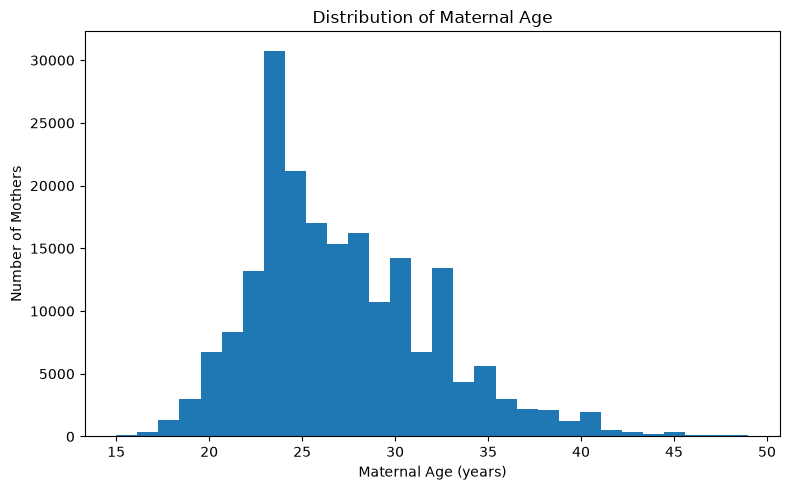

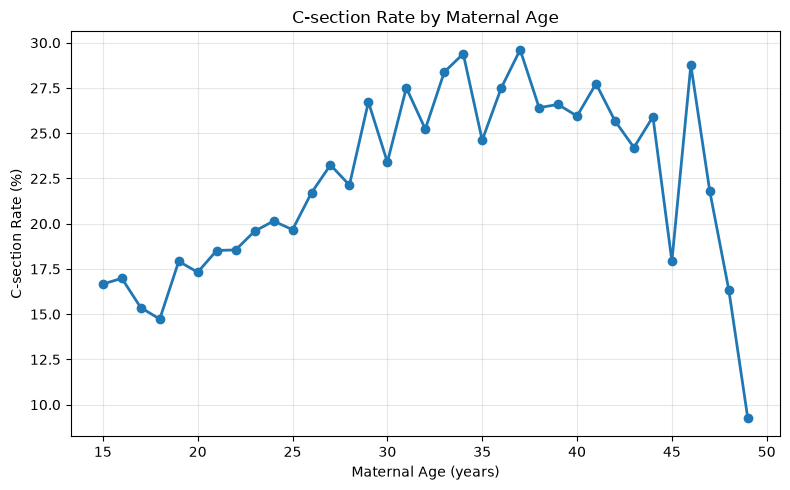

In [8]:
# Analyze maternal age and save its delivery-group summary
maternal_age_summary = analyze_numeric_feature(
    data=df_model,  # Use the final modeling dataset
    feature="maternal_age",  # Select maternal age
    feature_label="Maternal Age",  # Set the readable plot title
    x_label="Maternal Age (years)"  # Label the horizontal axis
)

#### 2.2 Body Mass Index (BMI)

Maternal BMI summary:


count    195813.000000
mean         21.984591
std           4.056144
min          12.020000
25%          19.170000
50%          21.400000
75%          24.040000
max          59.990000
Name: bmi, dtype: float64

Missing values: 5498 (2.73%)
Maternal BMI by delivery type:


,count,mean,median,std
Vaginal delivery,152512,21.54,21.05,3.74
Cesarean section,43301,23.55,22.93,4.68


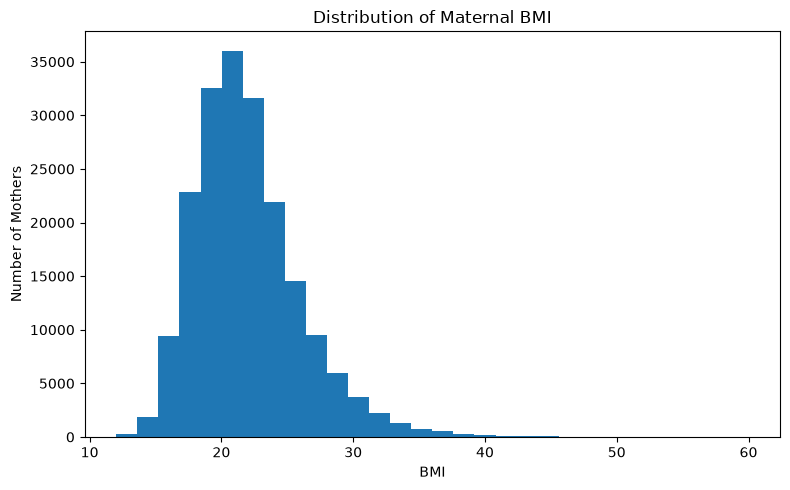

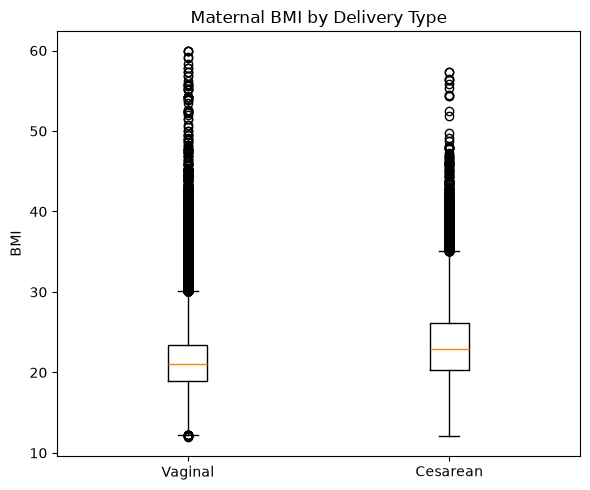

In [9]:
# Analyze maternal BMI and save its delivery-group summary
bmi_summary = analyze_numeric_feature(
    data=df_model,  # Use the final modeling dataset
    feature="bmi",  # Select maternal BMI
    feature_label="Maternal BMI",  # Set the readable plot title
    x_label="BMI"  # Label the horizontal axis
)

### 3. Socioeconomic Characteristics

#### 3.1 Years of Education

Years of Education summary:


count    201311.000000
mean          7.995395
std           5.055247
min           0.000000
25%           5.000000
50%           9.000000
75%          12.000000
max          20.000000
Name: education_years, dtype: float64

Missing values: 0 (0.00%)
Years of Education by delivery type:


,count,mean,median,std
Vaginal delivery,156569,7.39,8.0,4.99
Cesarean section,44742,10.12,10.0,4.71


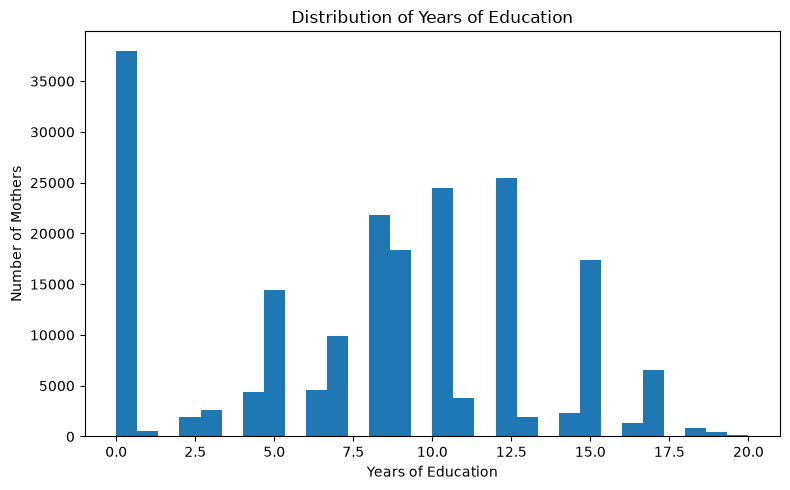

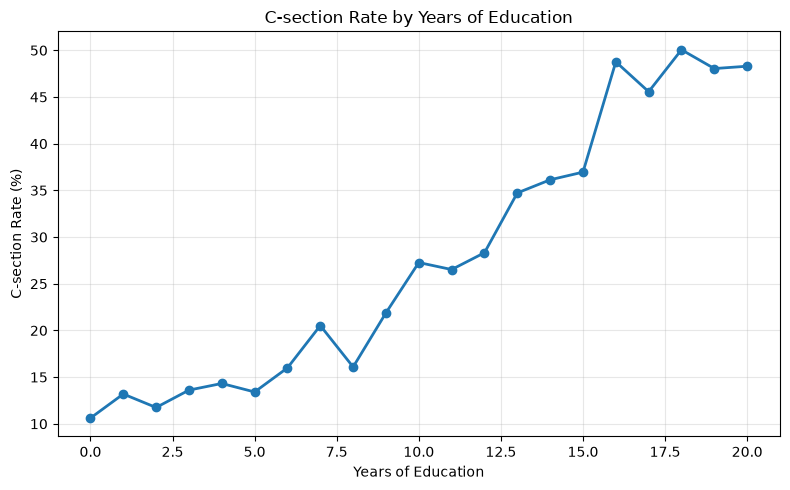

In [10]:
# Analyze education years and save its delivery-group summary
education_summary = analyze_numeric_feature(
    data=df_model,  # Use the final modeling dataset
    feature="education_years",  # Select completed education years
    feature_label="Years of Education",  # Set the readable plot title
    x_label="Years of Education"  # Label the horizontal axis
)

#### 3.2 Wealth Index

Wealth Index summary:


count    201311.000000
mean          2.794800
std           1.374651
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max           5.000000
Name: wealth_index, dtype: float64

Missing values: 0 (0.00%)
Wealth Index by delivery type:


,count,mean,median,std
Vaginal delivery,156569,2.61,2.0,1.35
Cesarean section,44742,3.43,4.0,1.28


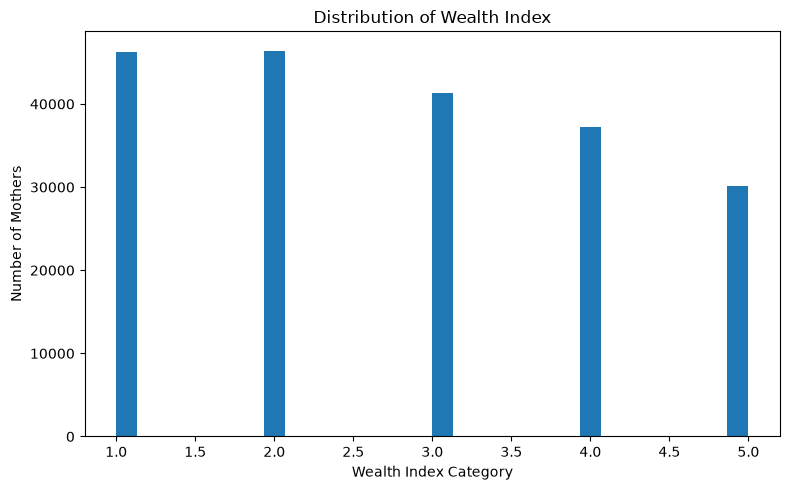

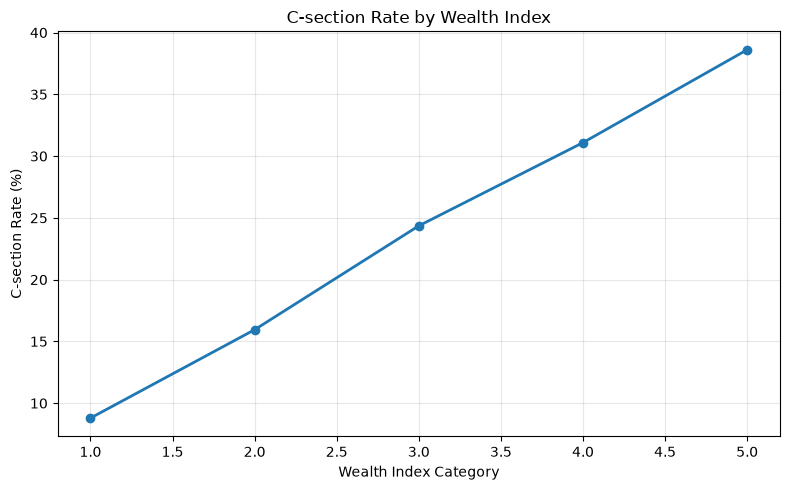

In [11]:
# Analyze the wealth index and compare it across delivery types

# Run the reusable numeric EDA function
wealth_summary = analyze_numeric_feature(
    data=df_model,                    # Use the cleaned modeling dataset
    feature="wealth_index",           # Select the wealth index variable
    feature_label="Wealth Index",     # Set the plot titles
    x_label="Wealth Index Category"   # Label the horizontal axis
)

#### 3.3 Place of Residence


Missing values: 0 (0.00%)
Place of Residence distribution:


,count,percent
residence,,
1,44195,21.95
2,157116,78.05


Place of Residence by delivery type:


,count,csection_rate
residence,,
1,44195,32.9
2,157116,19.22


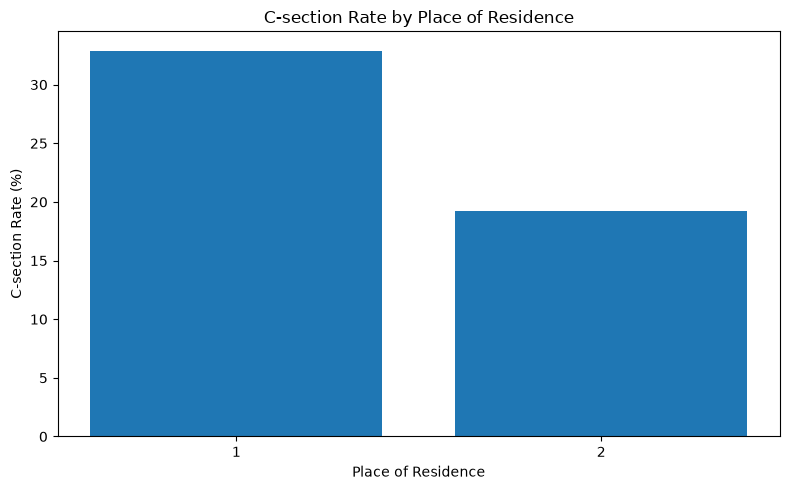

In [14]:
# Analyze the place of residence and compare it across delivery types

# Run the reusable categorical EDA function
residence_summary = analyze_categorical_feature(
    data=df_model,                  # Use the cleaned modeling dataset
    feature="residence",            # Select the residence variable
    feature_label="Place of Residence"   # Set the table and plot titles
)

#### 3.4 Religion

Missing values: 0 (0.00%)
Religion distribution:


,count,percent
religion,,
1,152579,75.79
2,28315,14.07
3,12238,6.08
4,3932,1.95
5,1925,0.96
6,184,0.09
7,1,0.00
8,10,0.00
9,60,0.03


Religion by delivery type:


,count,csection_rate
religion,,
1,152579,21.95
2,28315,23.59
3,12238,17.71
4,3932,37.39
5,1925,23.84
6,184,39.67
7,1,0.0
8,10,10.0
9,60,15.0


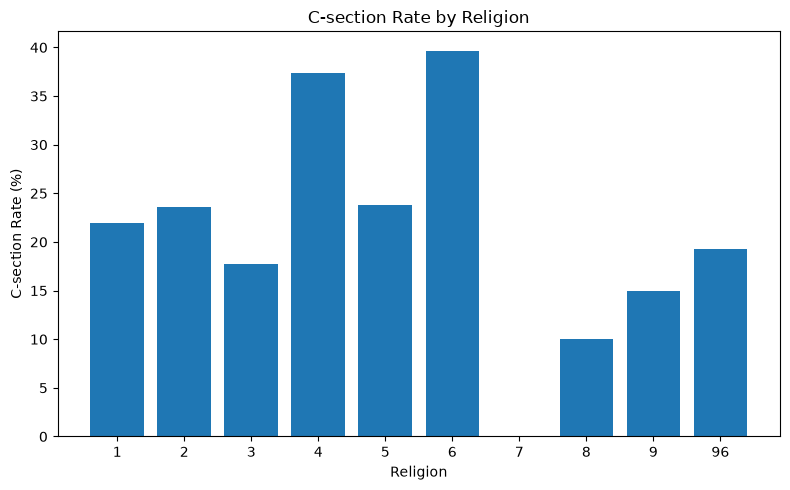

In [15]:
# Analyze religion and compare C-section rates across religious groups

# Run the reusable categorical EDA function
religion_summary = analyze_categorical_feature(
    data=df_model,              # Use the cleaned modeling dataset
    feature="religion",         # Select the religion variable
    feature_label="Religion"    # Set the table and plot titles
)

#### 3.5 Social Group

Missing values: 10552 (5.24%)
Social Group distribution:


,count,percent
social_group,,
1,41839,20.78
2,35352,17.56
3,80077,39.78
4,33491,16.64
<NA>,10552,5.24


Social Group by delivery type:


,count,csection_rate
social_group,,
1,41839,20.38
2,35352,13.25
3,80077,23.51
4,33491,30.39


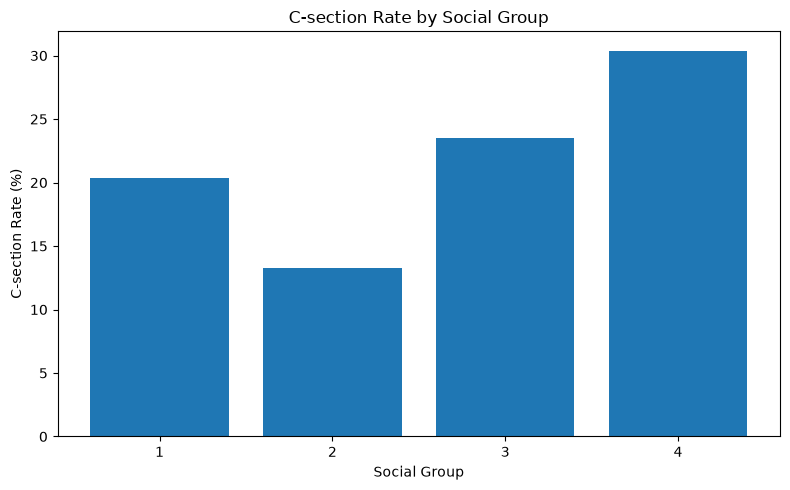

In [17]:
# Analyze social group and compare C-section rates across groups

# Run the reusable categorical EDA function
social_group_summary = analyze_categorical_feature(
    data=df_model,                    # Use the cleaned modeling dataset
    feature="social_group",           # Select the social group variable
    feature_label="Social Group"      # Set the table and plot titles
)

#### 3.6 Health Insurance Coverage

Missing values: 0 (0.00%)
Health Insurance distribution:


,count,percent
health_insurance,,
0,146026,72.54
1,55285,27.46


Health Insurance by delivery type:


,count,csection_rate
health_insurance,,
0,146026,22.47
1,55285,21.58


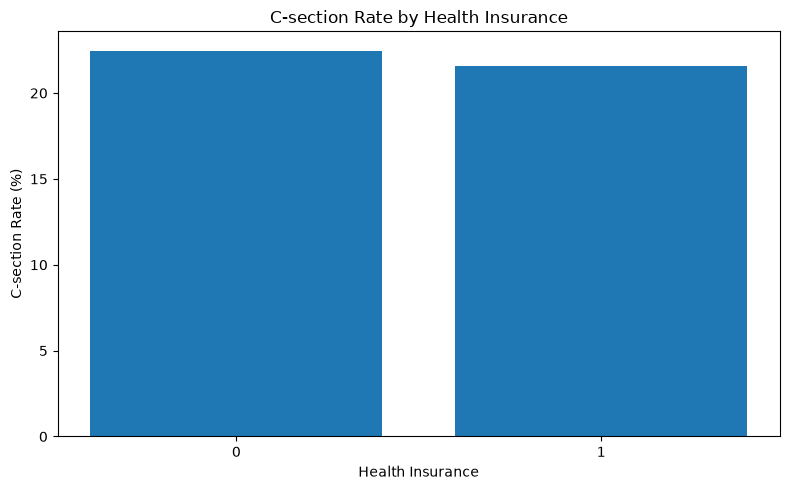

In [18]:
# Analyze health insurance coverage and compare C-section rates

# Run the reusable categorical EDA function
insurance_summary = analyze_categorical_feature(
    data=df_model,                          # Use the cleaned modeling dataset
    feature="health_insurance",             # Select the health insurance variable
    feature_label="Health Insurance"
)

#### 4.1 Birth Order

Birth Order summary:


count    201311.000000
mean          2.027435
std           1.224486
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          16.000000
Name: birth_order, dtype: float64

Missing values: 0 (0.00%)
Birth Order by delivery type:


,count,mean,median,std
Vaginal delivery,156569,2.12,2.0,1.29
Cesarean section,44742,1.70,2.0,0.90


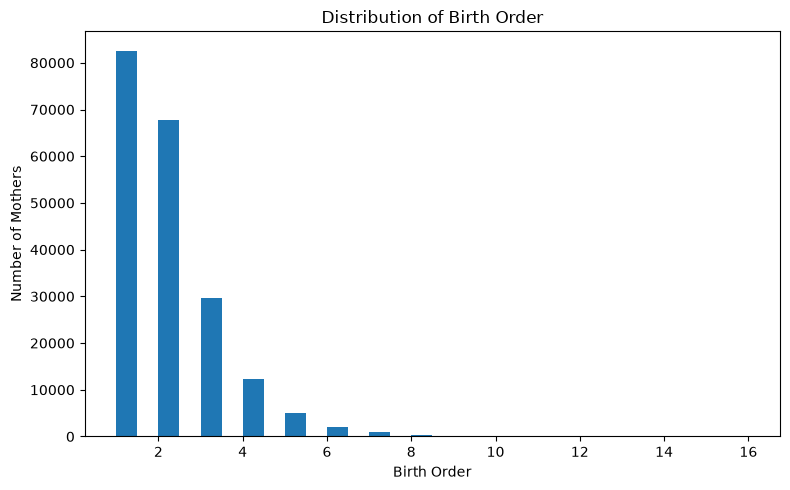

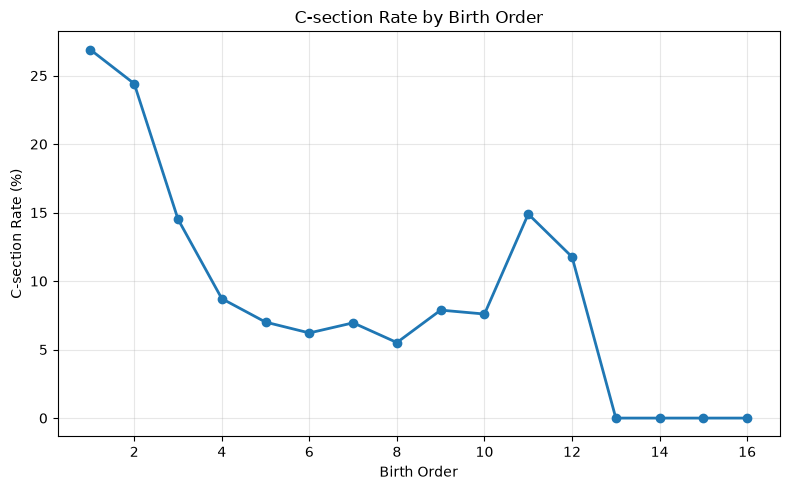

In [19]:
# Analyze birth order and compare it across delivery types

# Run the reusable numeric EDA function
birth_order_summary = analyze_numeric_feature(
    data=df_model,                    # Use the cleaned modeling dataset
    feature="birth_order",            # Select the birth order variable
    feature_label="Birth Order",      # Set the plot titles
    x_label="Birth Order"
)

#### 4.2 Total Children Ever Born

Total Children Ever Born summary:


count    201311.000000
mean          2.276940
std           1.258449
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          16.000000
Name: total_children_ever_born, dtype: float64

Missing values: 0 (0.00%)
Total Children Ever Born by delivery type:


,count,mean,median,std
Vaginal delivery,156569,2.40,2.0,1.32
Cesarean section,44742,1.86,2.0,0.92


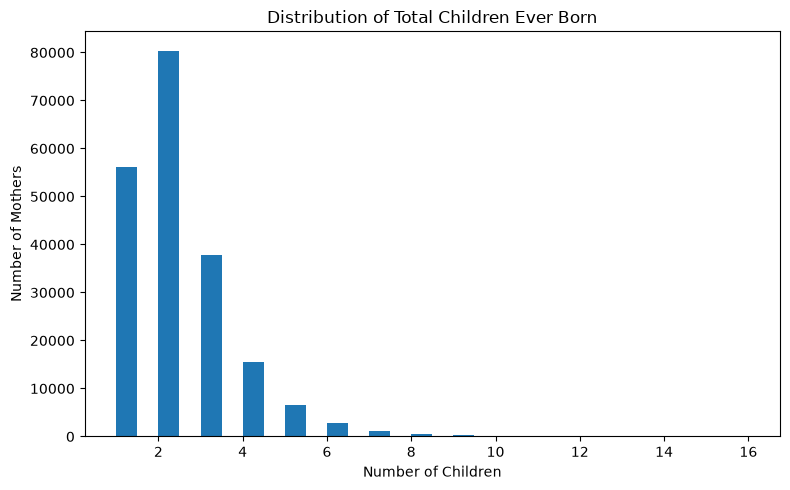

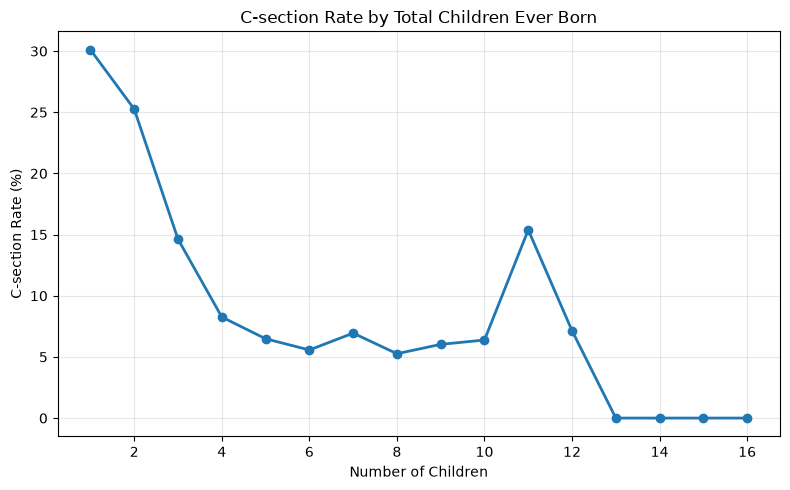

In [20]:
# Analyze the total number of children ever born and compare it across delivery types

# Run the reusable numeric EDA function
children_summary = analyze_numeric_feature(
    data=df_model,                            # Use the cleaned modeling dataset
    feature="total_children_ever_born",       # Select the total children variable
    feature_label="Total Children Ever Born", # Set the plot titles
    x_label="Number of Children"
)

#### 4.3 Preceding Birth Interval

Preceding Birth Interval summary:


count     117970.0
mean     40.153963
std      24.853467
min            6.0
25%           23.0
50%           33.0
75%           50.0
max          280.0
Name: preceding_birth_interval, dtype: Float64

Missing values: 83341 (41.40%)
Preceding Birth Interval by delivery type:


,count,mean,median,std
Vaginal delivery,95863,38.8,32.0,23.71
Cesarean section,22107,46.02,38.0,28.58


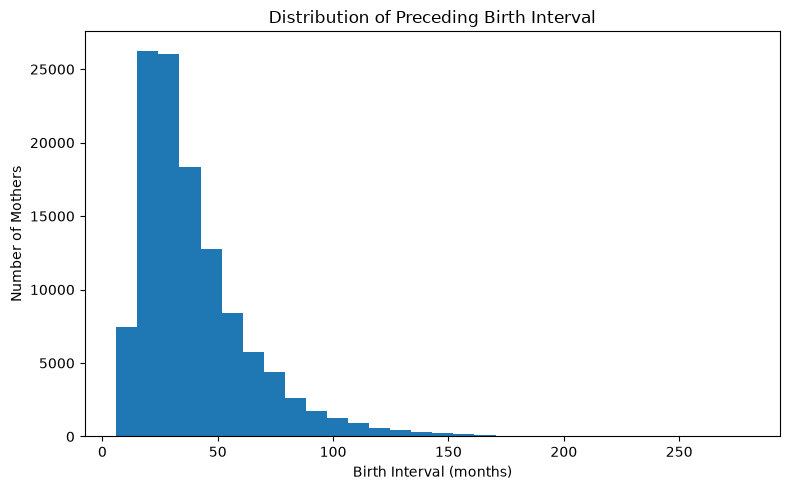

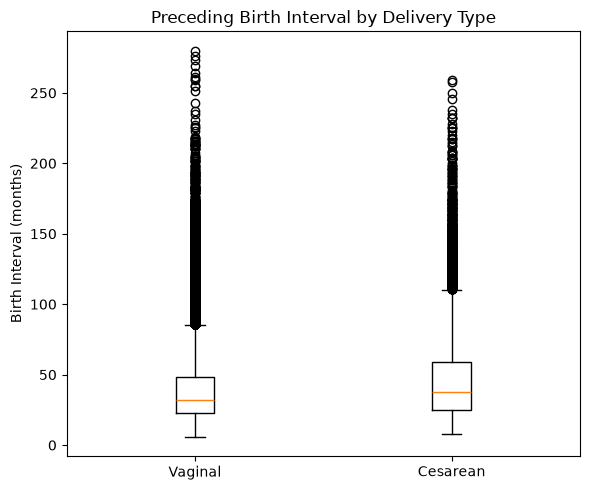

In [21]:
# Analyze the preceding birth interval and compare it across delivery types

# Run the reusable numeric EDA function
birth_interval_summary = analyze_numeric_feature(
    data=df_model,                                   # Use the cleaned modeling dataset
    feature="preceding_birth_interval",              # Select the birth interval variable
    feature_label="Preceding Birth Interval",
    x_label="Birth Interval (months)"
)

#### 4.4 Age at First Birth

Age at First Birth summary:


count    201311.000000
mean         21.598263
std           3.753053
min           6.000000
25%          19.000000
50%          21.000000
75%          24.000000
max          48.000000
Name: age_at_first_birth, dtype: float64

Missing values: 0 (0.00%)
Age at First Birth by delivery type:


,count,mean,median,std
Vaginal delivery,156569,21.20,21.0,3.51
Cesarean section,44742,22.98,22.0,4.22


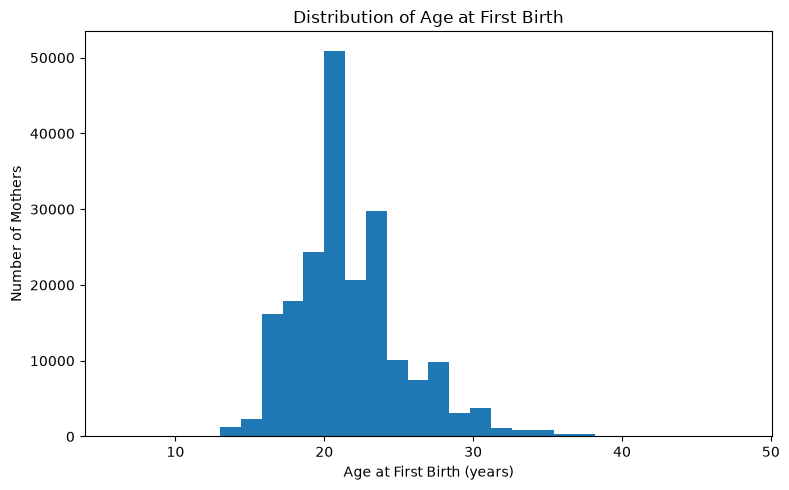

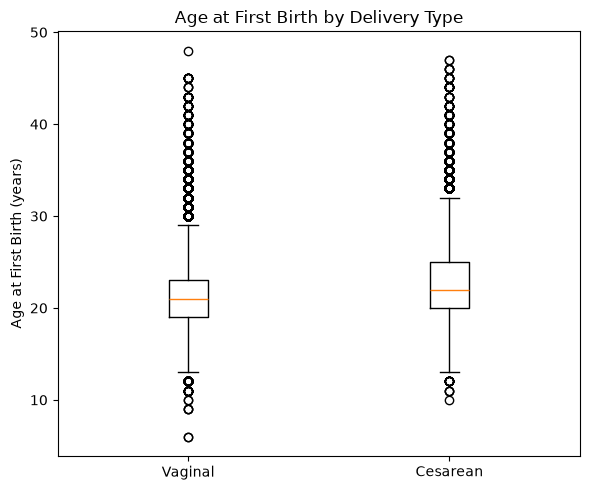

In [22]:
# Analyze age at first birth and compare it across delivery types

# Run the reusable numeric EDA function
first_birth_age_summary = analyze_numeric_feature(
    data=df_model,                         # Use the cleaned modeling dataset
    feature="age_at_first_birth",          # Select the age at first birth variable
    feature_label="Age at First Birth",    # Set the plot titles
    x_label="Age at First Birth (years)"
)

#### 4.5 Twin Birth

Missing values: 0 (0.00%)
Twin Birth distribution:


,count,percent
twin_order,,
0,197857,98.28
1,1718,0.85
2,1717,0.85
3,19,0.01


Twin Birth by delivery type:


,count,csection_rate
twin_order,,
0,197857,21.88
1,1718,42.03
2,1717,42.17
3,19,63.16


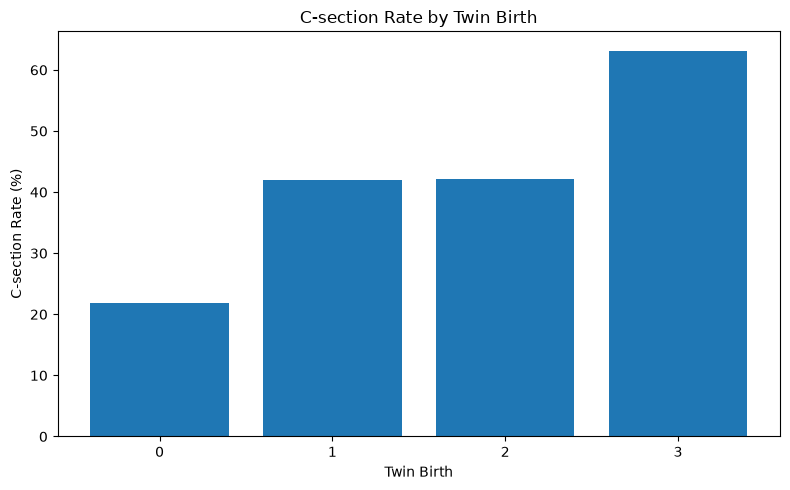

In [23]:
# Analyze twin birth and compare C-section rates

# Run the reusable categorical EDA function
twin_summary = analyze_categorical_feature(
    data=df_model,                 # Use the cleaned modeling dataset
    feature="twin_order",          # Select the twin birth variable
    feature_label="Twin Birth"
)

### Statistical Comparison of Numeric Variables

In [ ]:
# Import the Mann-Whitney U test
from scipy.stats import mannwhitneyu

# Import pandas for creating the result table
import pandas as pd

# Define a function for comparing one numeric variable across delivery groups
def compare_numeric_feature(data, feature_name):

    # Select valid values from vaginal deliveries
    vaginal_values = data.loc[
        data["csection"] == 0,
        feature_name
    ].dropna()

    # Select valid values from Cesarean deliveries
    csection_values = data.loc[
        data["csection"] == 1,
        feature_name
    ].dropna()

    # Perform the two-sided Mann-Whitney U test
    u_statistic, p_value = mannwhitneyu(
        vaginal_values,
        csection_values,
        alternative="two-sided"
    )

    # Calculate the number of vaginal-delivery observations
    n_vaginal = len(vaginal_values)

    # Calculate the number of Cesarean-delivery observations
    n_csection = len(csection_values)

    # Calculate the rank-biserial effect size
    effect_size = 1 - (
        2 * u_statistic
        / (n_vaginal * n_csection)
    )

    # Use the absolute value to classify effect magnitude
    absolute_effect = abs(effect_size)

    # Label effects below 0.10 as negligible
    if absolute_effect < 0.10:
        effect_label = "Negligible"

    # Label effects from 0.10 to below 0.30 as small
    elif absolute_effect < 0.30:
        effect_label = "Small"

    # Label effects from 0.30 to below 0.50 as moderate
    elif absolute_effect < 0.50:
        effect_label = "Moderate"

    # Label effects of 0.50 or more as large
    else:
        effect_label = "Large"

    # Calculate the median for vaginal deliveries
    vaginal_median = vaginal_values.median()

    # Calculate the median for Cesarean deliveries
    csection_median = csection_values.median()

    # Return the results as one dictionary
    return {
        "feature": feature_name,
        "vaginal_n": n_vaginal,
        "csection_n": n_csection,
        "vaginal_median": vaginal_median,
        "csection_median": csection_median,
        "median_difference": csection_median - vaginal_median,
        "u_statistic": u_statistic,
        "p_value": p_value,
        "rank_biserial_effect": effect_size,
        "effect_magnitude": effect_label
    }

# List the numeric variables already analyzed
completed_numeric_features = [
    "maternal_age",
    "bmi",
    "education_years"
]

# Run the comparison function for each completed variable
numeric_test_results = [
    compare_numeric_feature(df_model, feature)
    for feature in completed_numeric_features
]

# Convert the results into a dataframe
numeric_test_summary = pd.DataFrame(numeric_test_results)

# Round the readable numerical results
numeric_test_summary[
    [
        "vaginal_median",
        "csection_median",
        "median_difference",
        "rank_biserial_effect"
    ]
] = numeric_test_summary[
    [
        "vaginal_median",
        "csection_median",
        "median_difference",
        "rank_biserial_effect"
    ]
].round(3)

# Display the completed statistical comparison table
display(numeric_test_summary)

,feature,vaginal_n,csection_n,vaginal_median,csection_median,median_difference,u_statistic,p_value,rank_biserial_effect,effect_magnitude
0,maternal_age,156569,44742,26.00,27.00,1.00,3.150445e+09,1.419885e-232,0.101,Small
1,bmi,152512,43301,21.05,22.93,1.88,2.422217e+09,0.000000e+00,0.266,Small
2,education_years,156569,44742,8.00,10.00,2.00,2.401544e+09,0.000000e+00,0.314,Moderate


In [24]:
# Display all column names in df_model
print(df_model.columns.tolist())

['respondent_id', 'birth_index', 'cluster_number', 'household_number', 'respondent_line_number', 'sample_weight', 'primary_sampling_unit', 'sample_stratum_v022', 'sample_stratum_v023', 'state', 'district', 'csection', 'delivery_place_code', 'facility_type', 'maternal_age', 'education_years', 'wealth_index', 'residence', 'religion', 'social_group', 'health_insurance', 'birth_order', 'total_children_ever_born', 'preceding_birth_interval', 'age_at_first_birth', 'twin_order', 'bmi', 'first_anc_timing', 'anc_visits', 'anc_doctor', 'anc_nurse_midwife', 'anc_traditional_attendant', 'anc_community_worker', 'anc_anganwadi_worker', 'anc_asha_worker', 'anc_other_provider', 'no_anc_provider', 'weight_measured_during_pregnancy', 'bp_measured_during_pregnancy', 'urine_sample_during_pregnancy', 'blood_sample_during_pregnancy', 'told_about_pregnancy_complications', 'counselled_vaginal_bleeding', 'counselled_convulsions', 'counselled_prolonged_labour', 'counselled_severe_abdominal_pain', 'counselled_hi